# Skill Manifold — Comparison B (Gromov–Wasserstein)

Interactive walkthrough of `pipeline/skill_manifold_gw.py`. We compare two independent **skill manifolds**:

1. **JIGSAWS** — dVRK robotic surgery video: three tasks (Suturing, Knot_Tying, Needle_Passing), 8 surgeons, per-trial GRS + 6 OSATS sub-scores.
2. **EEG/Eye simulator** — da Vinci Mimic: 25 participants × 27 tasks × per-try performance 0–100.

The datasets have different dimensionality, different subjects, and no shared task taxonomy. **Gromov–Wasserstein** is the right tool because it compares intra-set pairwise geometry only.

**Question.** After conditioning out task, subject, and other nuisances, does the residual *skill geometry* on each side have the same structure?

Run all cells top-to-bottom; expect ≤ 30 s on the real dataset.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# Swallow the protobuf MessageFactory.GetPrototype tracebacks that
# some tensorboard-adjacent imports emit at autoreload startup.
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass


import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name != 'surgical_gestures_skills_manifold':
    REPO = REPO.parent   # notebook is in pipeline/
sys.path.insert(0, str(REPO / 'src'))

from skill_manifold.io import (
    CONFIG_DIR, JIGSAWS_OSATS_COLUMNS, data_root, load_config,
)
from skill_manifold.features_jigsaws import (
    build_jigsaws_feature_frame,
    feature_column_names as jigsaws_feat_cols,
    zscore_features,
)
from skill_manifold.features_eeg_eye import (
    build_eeg_eye_feature_frame,
    feature_column_names as eeg_feat_cols,
    load_task_module_map,
)
from skill_manifold.residualize import residualize
from skill_manifold.binning import TIER_NAMES, add_tier_column
from skill_manifold.rdms import centroid_rdm, pairwise_cosine_rdm
from skill_manifold.gw import (
    entropic_gromov_wasserstein,
    gromov_wasserstein_centroids,
    permutation_null_centroid,
)

cfg = load_config('skill_manifold.yaml')
ROOT = data_root(None)
print('data root:', ROOT)
print('config:   ', cfg)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

data root: /Users/michaelhaidar/Library/Mobile Documents/com~apple~CloudDocs/Documents/Vanderbilt/Fall_25/Surgical Robotics/Surgical_Gestures
config:    {'seed': 1337, 'n_perms': 1000, 'gw_epsilon': 0.01, 'subsample_per_tier': 100, 'trial_null_n_subsamples': 30, 'modality_split_n_bootstraps': 8, 'modality_split_n_perms': 400, 'gripper_open_eps': 1e-06, 'economy_clip': '1.0e6', 'try_filter': 1, 'gestures_pool': ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G8', 'G9', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15'], 'osats_axes': ['respect_for_tissue', 'suture_needle_handling', 'time_and_motion', 'flow_of_operation', 'overall_performance', 'quality_of_final_product']}


## Step 1 — JIGSAWS feature extraction

Per trial: 14-dim gesture histogram + per-arm Slave-Left/Slave-Right kinematics summaries (12 scalars each) + trial duration → **39 dims**. Z-scored across the pooled JIGSAWS set.

In [2]:
gp = list(cfg['gestures_pool'])
jf = build_jigsaws_feature_frame(
    ROOT, gp,
    gripper_open_eps=float(cfg['gripper_open_eps']),
    economy_clip=float(cfg['economy_clip']),
)
j_cols = jigsaws_feat_cols(gp)
jf = zscore_features(jf, j_cols)
print(f'JIGSAWS trials: {len(jf)}   feature dim: {len(j_cols)}')
jf[['trial_id', 'task', 'surgeon', 'skill', 'grs_total'] + j_cols[:4]].head()

JIGSAWS trials: 103   feature dim: 39


,trial_id,task,surgeon,skill,grs_total,gest_G1,gest_G2,gest_G3,gest_G4
0,Knot_Tying_B001,Knot_Tying,B,N,13,-1.016041,-0.948707,-1.077075,-1.233897
1,Knot_Tying_B002,Knot_Tying,B,N,9,-1.016041,-0.948707,-1.077075,-1.233897
2,Knot_Tying_B003,Knot_Tying,B,N,11,-1.016041,-0.948707,-1.077075,-1.233897
3,Knot_Tying_B004,Knot_Tying,B,N,8,-1.016041,-0.948707,-1.077075,-1.233897
4,Knot_Tying_C001,Knot_Tying,C,I,20,-1.016041,-0.948707,-1.077075,-1.233897


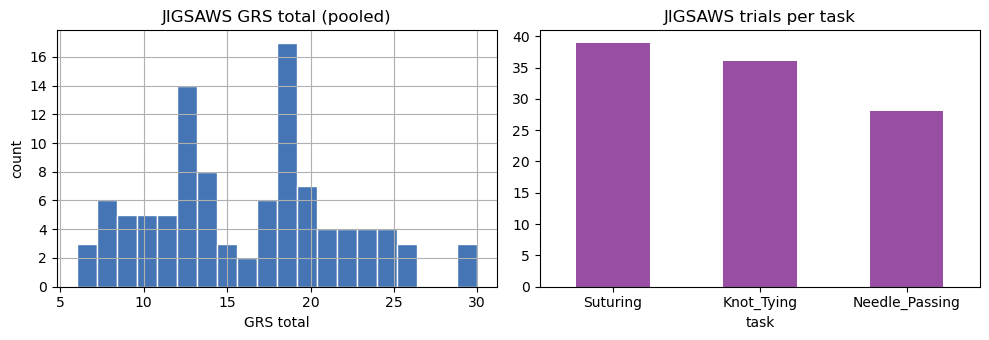

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
jf['grs_total'].hist(bins=20, ax=axes[0], color='#4575b4', edgecolor='white')
axes[0].set_title('JIGSAWS GRS total (pooled)')
axes[0].set_xlabel('GRS total'); axes[0].set_ylabel('count')
jf['task'].value_counts().plot.bar(ax=axes[1], color='#984ea3')
axes[1].set_title('JIGSAWS trials per task'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Step 2 — EEG/Eye simulator feature extraction

Per Try==1 trial: mean-pooled Phase 1 `baseline_embeddings` (64) + mean-pooled `pc_embeddings` (64) + 18-dim eye summary reconstructed from Phase 2 components → **146 dims**.

> ⚠ The cached `fingerprint` key is absent on ~91% of trials, so we rebuild an equivalent vector from `eye_state_summary`, `eye_transition_summary`, `pupil_summary`, `event_summary` — all of which are present in every trial.

In [4]:
mod_map = load_task_module_map(CONFIG_DIR / 'skill_manifold_task_modules.yaml')
ef = build_eeg_eye_feature_frame(ROOT, mod_map, try_filter=int(cfg['try_filter']))
e_cols = eeg_feat_cols()
# Z-score per feature on the EEG/Eye side.
for c in e_cols:
    v = ef[c].to_numpy(float); sd = v.std()
    ef[c] = ((v - v.mean()) / sd) if sd > 1e-12 else 0.0
print(f'EEG/Eye trials (Try==1, both cache hits): {len(ef)}   feature dim: {len(e_cols)}')
ef[['trial_id', 'subject_id', 'task_id', 'task_module', 'age', 'performance']].head()

EEG/Eye trials (Try==1, both cache hits): 510   feature dim: 146


,trial_id,subject_id,task_id,task_module,age,performance
0,10_10_1,10,10,camera_scaling,34.0,95.0
1,10_11_1,10,11,camera_scaling,34.0,63.0
2,10_12_1,10,12,ring_walk,34.0,97.0
3,10_13_1,10,13,ring_walk,34.0,79.0
4,10_14_1,10,14,ring_walk,34.0,82.0


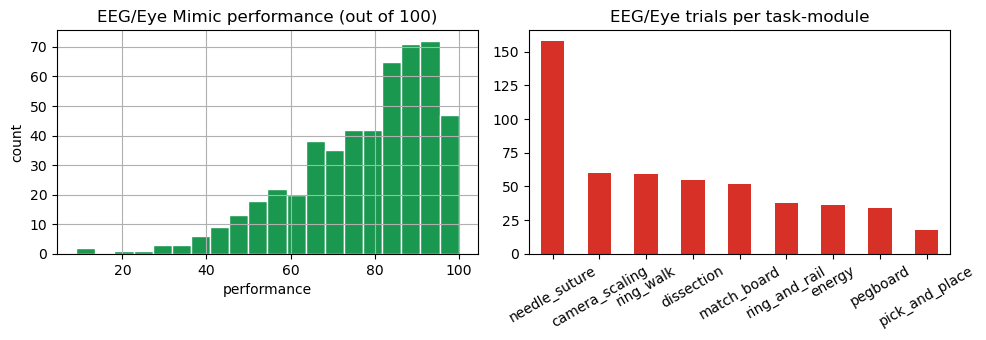

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
ef['performance'].hist(bins=20, ax=axes[0], color='#1a9850', edgecolor='white')
axes[0].set_title('EEG/Eye Mimic performance (out of 100)')
axes[0].set_xlabel('performance'); axes[0].set_ylabel('count')
ef['task_module'].value_counts().plot.bar(ax=axes[1], color='#d73027')
axes[1].set_title('EEG/Eye trials per task-module')
axes[1].tick_params(axis='x', rotation=30); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

## Step 3 — Nuisance residualization

We fit `feature ~ nuisances` with OLS and keep the residuals. **JIGSAWS nuisances:** task (3 levels), surgeon (8 levels), trial index within (surgeon,task). **EEG/Eye nuisances:** task_module (9 levels), subject_id (25 levels), dominant_hand (2 levels), age (ordinal).

JIGSAWS  max R^2 on features: 0.945   max R^2 after residualizing: 2.22e-16
EEG/Eye  max R^2 on features: 0.655   max R^2 after residualizing: 3.33e-16


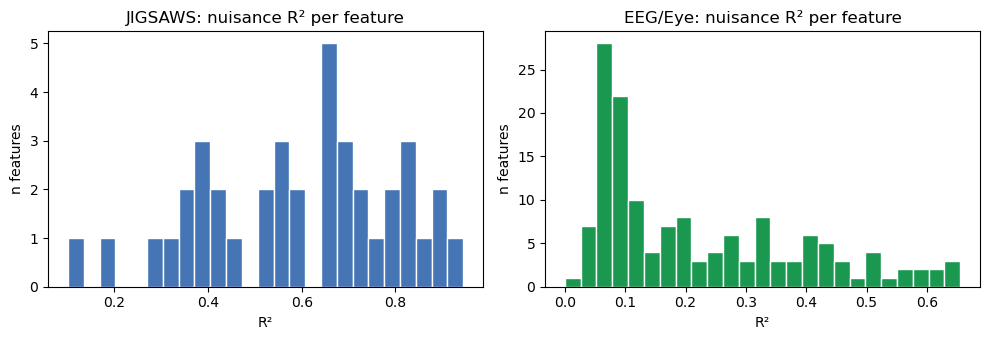

In [6]:
jr = residualize(jf, j_cols,
                 categorical=['task', 'surgeon'],
                 ordinal=['trial_index_within_surgeon_task'])
er = residualize(ef, e_cols,
                 categorical=['task_module', 'subject_id', 'dominant_hand'],
                 ordinal=['age'])
print(f'JIGSAWS  max R^2 on features: {jr.r2_per_feature.max():.3f}   '
      f'max R^2 after residualizing: {jr.post_fit_r2.max():.2e}')
print(f'EEG/Eye  max R^2 on features: {er.r2_per_feature.max():.3f}   '
      f'max R^2 after residualizing: {er.post_fit_r2.max():.2e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(jr.r2_per_feature, bins=25, color='#4575b4', edgecolor='white')
axes[0].set_title('JIGSAWS: nuisance R² per feature')
axes[0].set_xlabel('R²'); axes[0].set_ylabel('n features')
axes[1].hist(er.r2_per_feature, bins=25, color='#1a9850', edgecolor='white')
axes[1].set_title('EEG/Eye: nuisance R² per feature')
axes[1].set_xlabel('R²'); axes[1].set_ylabel('n features')
plt.tight_layout(); plt.show()

## Step 4 — Tertile binning

JIGSAWS → tertiles of GRS total. EEG/Eye → tertiles of Mimic performance. These are the **Low / Mid / High** skill tiers used everywhere downstream.

JIGSAWS GRS cutoffs: q33 = 13, q66 = 19
EEG/Eye performance cutoffs: q33 = 72, q66 = 88


,JIGSAWS,EEG/Eye
tier,,
Low,38,171
Mid,36,180
High,29,159


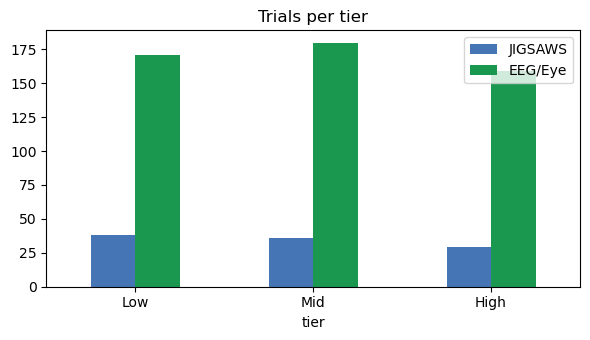

In [7]:
jr_df, j_cut = add_tier_column(jr.residuals, 'grs_total')
er_df, e_cut = add_tier_column(er.residuals, 'performance')
print(f'JIGSAWS GRS cutoffs: q33 = {j_cut.q33:g}, q66 = {j_cut.q66:g}')
print(f'EEG/Eye performance cutoffs: q33 = {e_cut.q33:g}, q66 = {e_cut.q66:g}')

cts = pd.DataFrame({
    'JIGSAWS': jr_df['tier'].value_counts().reindex(TIER_NAMES),
    'EEG/Eye': er_df['tier'].value_counts().reindex(TIER_NAMES),
})
display(cts)

ax = cts.plot.bar(figsize=(6, 3.5), color=['#4575b4', '#1a9850'])
ax.set_title('Trials per tier'); ax.set_xlabel('tier'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Step 5 — Centroid RDMs (Low / Mid / High)

Within each dataset: mean residualized feature vector per tier → 3 centroids → 3×3 cosine-distance RDM.

These are the two things GW compares.

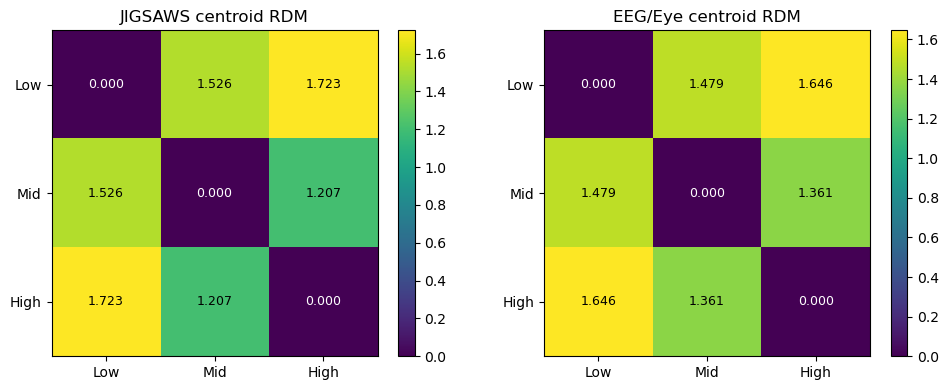

In [8]:
jf_mat = jr_df[j_cols].to_numpy(float)
ef_mat = er_df[e_cols].to_numpy(float)
RDM_J = centroid_rdm(jf_mat, jr_df['tier'].to_numpy(), TIER_NAMES)
RDM_E = centroid_rdm(ef_mat, er_df['tier'].to_numpy(), TIER_NAMES)

def _heat(ax, M, title):
    im = ax.imshow(M, cmap='viridis')
    ax.set_xticks(range(3), TIER_NAMES); ax.set_yticks(range(3), TIER_NAMES)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{M[i,j]:.3f}', ha='center', va='center',
                    color='white' if M[i,j] < M.max() * 0.6 else 'black', fontsize=9)
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im1 = _heat(axes[0], RDM_J, 'JIGSAWS centroid RDM')
im2 = _heat(axes[1], RDM_E, 'EEG/Eye centroid RDM')
fig.colorbar(im1, ax=axes[0], fraction=0.046)
fig.colorbar(im2, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Step 6 — Gromov–Wasserstein distance + coupling

With uniform marginals and square loss, GW finds the transport plan that best aligns the two intra-set geometries. The **coupling** matrix tells us which source tier is mapped to which target tier.

GW distance = 0.007089
Argmax tier-to-tier assignment: {'Low': 'Low', 'Mid': 'Mid', 'High': 'High'}


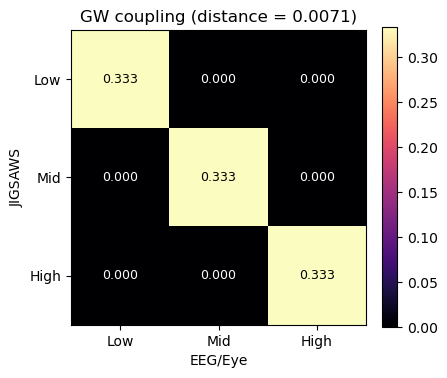

In [9]:
gw = gromov_wasserstein_centroids(RDM_J, RDM_E, TIER_NAMES)
print(f'GW distance = {gw.distance:.6f}')
print(f'Argmax tier-to-tier assignment: {gw.argmax_assignment}')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(gw.coupling, cmap='magma')
ax.set_xticks(range(3), TIER_NAMES); ax.set_yticks(range(3), TIER_NAMES)
ax.set_xlabel('EEG/Eye'); ax.set_ylabel('JIGSAWS')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{gw.coupling[i,j]:.3f}', ha='center', va='center',
                color='white' if gw.coupling[i,j] < 0.2 else 'black', fontsize=9)
ax.set_title(f'GW coupling (distance = {gw.distance:.4f})')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Step 7 — Permutation null

Under the null, tier labels carry no feature-space structure. We shuffle tier assignments on each side independently (preserving tier counts), recompute centroids → RDMs → GW, and compare the observed value to the null distribution.

p = (1 + #{null ≤ observed}) / (1 + n). **Small p means the observed alignment is unusually tight.**

observed GW     = 0.007089
null mean ± std = 0.011142 ± 0.015636
p-value         = 0.5714
z-score         = -0.259
n permutations  = 1000  (degenerate dropped: 0)


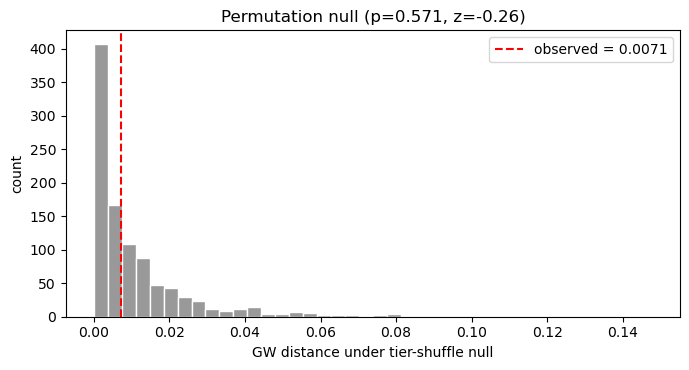

In [10]:
null = permutation_null_centroid(
    jf_mat, jr_df['tier'].to_numpy(),
    ef_mat, er_df['tier'].to_numpy(),
    TIER_NAMES,
    n_perms=int(cfg['n_perms']),
    seed=int(cfg['seed']),
)
print(f"observed GW     = {null['observed']:.6f}")
print(f"null mean ± std = {null['null_mean']:.6f} ± {null['null_std']:.6f}")
print(f"p-value         = {null['p_value']:.4f}")
print(f"z-score         = {null['z_score']:.3f}")
print(f"n permutations  = {null['n_permutations']}  (degenerate dropped: {null['n_degenerate']})")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(null['null'], bins=40, color='#999', edgecolor='white')
ax.axvline(null['observed'], color='red', linestyle='--',
           label=f"observed = {null['observed']:.4f}")
ax.set_xlabel('GW distance under tier-shuffle null')
ax.set_ylabel('count')
ax.set_title(f"Permutation null (p={null['p_value']:.3f}, z={null['z_score']:.2f})")
ax.legend()
plt.tight_layout(); plt.show()

## Step 8 — OSATS axis-alignment

The JIGSAWS meta files record six OSATS sub-scores per trial. For each axis we re-bin JIGSAWS trials into tertiles of that single axis, rebuild `RDM_J_axis`, and run GW against the same `RDM_E`.

Which sub-dimension of expert-rated skill aligns tightest with the Mimic composite?

,gw,p,z
axis,,,
respect_for_tissue,0.0030,0.3035,-0.54
suture_needle_handling,0.0189,0.6816,-0.02
time_and_motion,0.0305,0.5075,-0.14
flow_of_operation,0.0803,0.8806,+1.13
overall_performance,0.0266,0.8010,+0.43
quality_of_final_product,0.0126,0.0647,-1.23


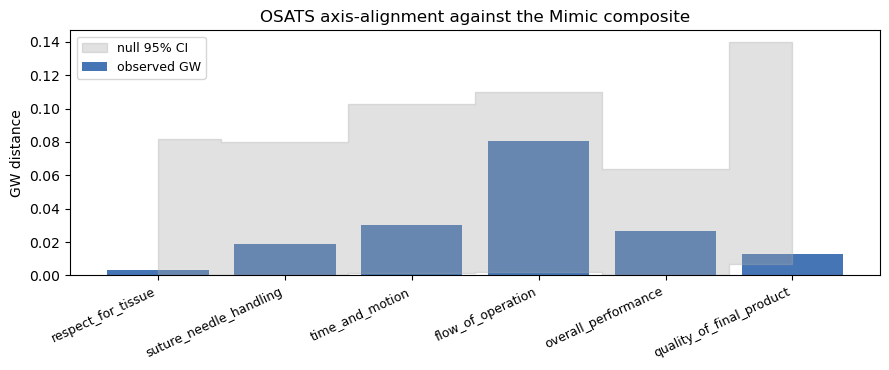

In [11]:
osats_rows = []
null_cis = []
for axis in JIGSAWS_OSATS_COLUMNS:
    colname = f'osats_{axis}'
    sub, _cut = add_tier_column(jr_df, colname, tier_col=f'tier_{axis}')
    R = centroid_rdm(sub[j_cols].to_numpy(float),
                     sub[f'tier_{axis}'].to_numpy(), TIER_NAMES)
    g = gromov_wasserstein_centroids(R, RDM_E, TIER_NAMES)
    n = permutation_null_centroid(
        sub[j_cols].to_numpy(float), sub[f'tier_{axis}'].to_numpy(),
        ef_mat, er_df['tier'].to_numpy(),
        TIER_NAMES, n_perms=max(200, int(cfg['n_perms']) // 5),
        seed=int(cfg['seed']))
    osats_rows.append({
        'axis': axis, 'gw': g.distance, 'p': n['p_value'], 'z': n['z_score'],
    })
    null_cis.append((float(np.quantile(n['null'], 0.025)),
                     float(np.quantile(n['null'], 0.975))))
osats_df = pd.DataFrame(osats_rows).set_index('axis')
display(osats_df.style.format({'gw': '{:.4f}', 'p': '{:.4f}', 'z': '{:+.2f}'}))

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(osats_df))
ax.bar(x, osats_df['gw'], color='#4575b4', label='observed GW')
lo = np.array([c[0] for c in null_cis]); hi = np.array([c[1] for c in null_cis])
ax.fill_between(x, lo, hi, color='#aaaaaa', alpha=0.35, step='mid', label='null 95% CI')
ax.set_xticks(x, osats_df.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('GW distance')
ax.set_title('OSATS axis-alignment against the Mimic composite')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Step 9 — Trial-level entropic GW (balanced sensitivity draw)

The **primary** trial-level analysis in Step 9a below uses every trial exactly once (NJ = 103, NE = 510). Before that we still run the historic **balanced 100-per-tier with replacement** draw so the 300×300 coupling heatmap is visualizable; that analysis is now a *sensitivity check*. It upsamples each JIGSAWS trial ~3× and therefore produces an artificially sharpened coupling — Step 9a is the honest result.

entropic GW distance = 0.066438   (N=100 per tier, epsilon=0.01)


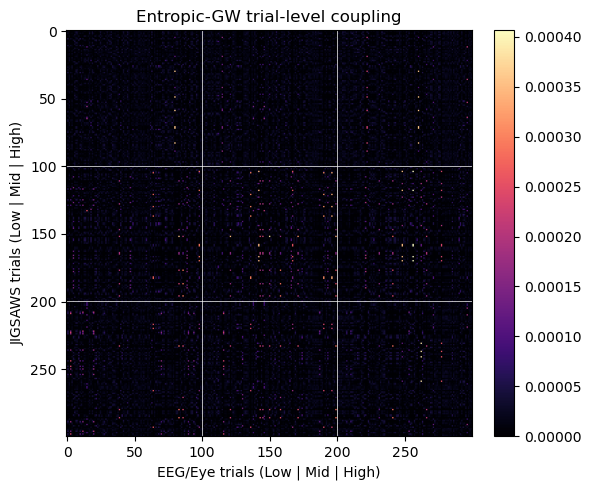

In [12]:
rng = np.random.default_rng(int(cfg['seed']))
N = int(cfg['subsample_per_tier'])

def _balanced(df, cols, n):
    parts_f, parts_t = [], []
    for t in TIER_NAMES:
        sub = df[df['tier'] == t]
        idx = rng.choice(len(sub), size=n, replace=len(sub) < n)
        parts_f.append(sub.iloc[idx][cols].to_numpy(float))
        parts_t.append(np.asarray(sub.iloc[idx]['tier']))
    return np.vstack(parts_f), np.concatenate(parts_t)

fj, tj = _balanced(jr_df, j_cols, N)
fe, te = _balanced(er_df, e_cols, N)
Cj = pairwise_cosine_rdm(fj); Ce = pairwise_cosine_rdm(fe)
egw = entropic_gromov_wasserstein(Cj, Ce, epsilon=float(cfg['gw_epsilon']))
print(f'entropic GW distance = {egw.distance:.6f}   (N={N} per tier, epsilon={cfg["gw_epsilon"]})')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(egw.coupling, cmap='magma', aspect='auto')
for k in (1, 2):
    ax.axhline(k * N - 0.5, color='white', linewidth=0.5)
    ax.axvline(k * N - 0.5, color='white', linewidth=0.5)
ax.set_xlabel('EEG/Eye trials (Low | Mid | High)')
ax.set_ylabel('JIGSAWS trials (Low | Mid | High)')
ax.set_title('Entropic-GW trial-level coupling')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Step 9a — All-trials block-diagonality null (primary)

**Why a second null, now on the full data.** The 3×3 centroid null in Step 7 is coarse; the balanced Step 9b null in v1 upsampled each JIGSAWS trial. Here we compute the entropic-GW coupling **once** on the full NJ × NE (103 × 510) problem with uniform marginals, aggregate to a 3×3 block-mass matrix `B`, and run the tier-shuffle null on that fixed coupling.

**Unbalanced tiers change the expected null.** Under independent tier shuffles, each cell's expected mass is `(n_j_a/NJ) · (n_e_b/NE)`, so the expected trace is
`Σ_a (n_j_a · n_e_a) / (NJ · NE)` — which is 1/3 only when both sides have exactly balanced tiers. With our tertiles that is approximately but not exactly true, so we report both observed and expected trace.

**Per-cell z-scores** are computed against the null of that diagonal cell alone. With K = 3 diagonal cells two-sided, the Bonferroni-corrected significance threshold is **|z| > 2.39**.

**What the per-cell z-scores decompose.** The aggregate diag_mass can hide directional structure — one tier can be strongly positive while the trace sits near the null mean. The per-cell z's expose that.

coupling shape        = (103, 510)
tier counts J / E     = [38, 36, 29] / [171, 180, 159]
pre-renorm drift      = row 5.20e-18, col 1.13e-11
observed diag_mass    = 0.3378
expected under null   = 0.3348
null mean / std       = 0.3349 / 0.0029
p-value               = 0.1528
trace z-score         = +1.007

per-cell diagonal z-scores (Bonferroni threshold |z| > 2.39):
     Low<->Low: obs 0.124 (exp 0.124)   z = +0.14
     Mid<->Mid: obs 0.126 (exp 0.123)   z = +1.76
     High<->High: obs 0.088 (exp 0.088)   z = +0.20


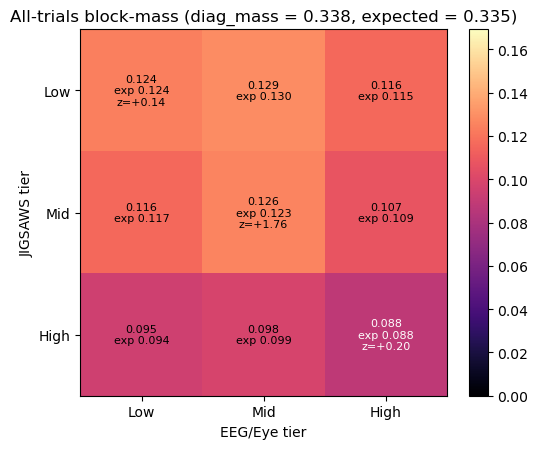

In [13]:
from skill_manifold.trial_null import (
    trial_level_block_null_all_trials, BONFERRONI_Z_THREE_CELLS,
)

# Sinkhorn renormalize a coupling onto exact doubly-stochastic marginals.
def _renorm(T, max_iter=5000, atol=1e-12):
    T = np.clip(np.asarray(T, float), 0, None)
    T = T / T.sum()
    for _ in range(max_iter):
        T = T * (1.0 / T.shape[0] / T.sum(axis=1, keepdims=True))
        T = T * (1.0 / T.shape[1] / T.sum(axis=0, keepdims=True))
        drift = max(np.max(np.abs(T.sum(axis=1) - 1.0 / T.shape[0])),
                    np.max(np.abs(T.sum(axis=0) - 1.0 / T.shape[1])))
        if drift < atol:
            break
    return T

def _egw_with_eps(Cj_i, Ce_i, eps):
    r = entropic_gromov_wasserstein(Cj_i, Ce_i, epsilon=float(eps))
    T = np.asarray(r.coupling, float)
    if max(np.max(np.abs(T.sum(axis=1) - 1 / T.shape[0])),
           np.max(np.abs(T.sum(axis=0) - 1 / T.shape[1]))) > 1e-9:
        T = _renorm(T)
    return float(r.distance), T

primary = trial_level_block_null_all_trials(
    features_j=jr_df[j_cols].to_numpy(float),
    tiers_j=jr_df['tier'].to_numpy(),
    features_e=er_df[e_cols].to_numpy(float),
    tiers_e=er_df['tier'].to_numpy(),
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=int(cfg['n_perms']),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_with_eps,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)

B_primary = np.asarray(primary['block_mass'])
Bexp = np.asarray(primary['expected_block_mass'])

print(f"coupling shape        = {primary['coupling_shape']}")
print(f"tier counts J / E     = {list(primary['tier_counts_j'])} / "
      f"{list(primary['tier_counts_e'])}")
print(f"pre-renorm drift      = row {primary['row_sum_drift']:.2e}, "
      f"col {primary['col_sum_drift']:.2e}")
print(f"observed diag_mass    = {primary['observed']:.4f}")
print(f"expected under null   = {primary['expected_trace_under_null']:.4f}")
print(f"null mean / std       = {primary['null_mean']:.4f} / {primary['null_std']:.4f}")
print(f"p-value               = {primary['p_value']:.4f}")
print(f"trace z-score         = {primary['z_score']:+.3f}")
print()
print('per-cell diagonal z-scores (Bonferroni threshold |z| > 2.39):')
for n, z, o, e in zip(primary['tier_names'], primary['per_cell_z'],
                       primary['per_cell_observed'], primary['per_cell_expected']):
    flag = '**' if abs(z) > BONFERRONI_Z_THREE_CELLS else '  '
    print(f"  {flag} {n}<->{n}: obs {o:.3f} (exp {e:.3f})   z = {z:+.2f}")

# Panel: block-mass heatmap annotated with observed, expected, and per-cell z.
fig, ax = plt.subplots(figsize=(5.5, 4.6))
vmax = max(B_primary.max(), float(Bexp.max()) * 1.3)
im = ax.imshow(B_primary, cmap='magma', vmin=0, vmax=vmax)
ax.set_xticks(range(3), TIER_NAMES); ax.set_yticks(range(3), TIER_NAMES)
ax.set_xlabel('EEG/Eye tier'); ax.set_ylabel('JIGSAWS tier')
for i in range(3):
    for j in range(3):
        label = f'{B_primary[i, j]:.3f}\nexp {Bexp[i, j]:.3f}'
        if i == j:
            label += f'\nz={primary["per_cell_z"][i]:+.2f}'
        ax.text(j, i, label, ha='center', va='center',
                color='white' if B_primary[i, j] < vmax * 0.55 else 'black',
                fontsize=8)
ax.set_title(f"All-trials block-mass (diag_mass = {primary['observed']:.3f}, "
             f"expected = {primary['expected_trace_under_null']:.3f})")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

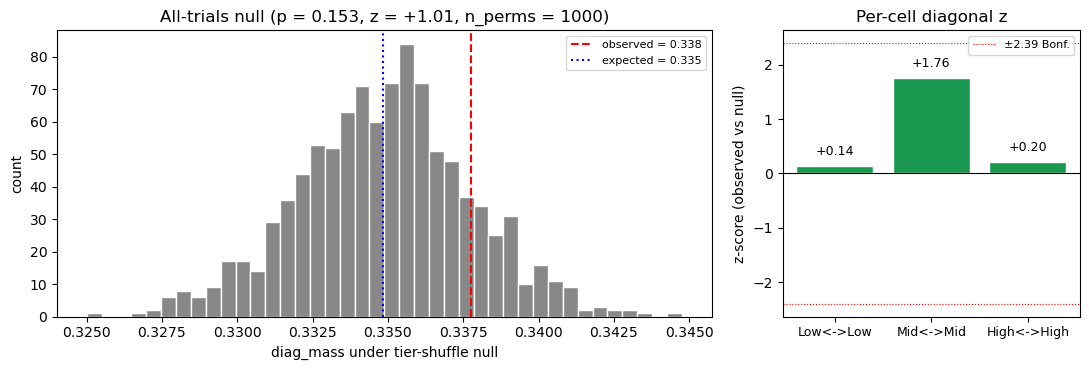

In [14]:
# Null histogram (all-trials) with BOTH observed trace and the tier-count-weighted
# expected trace drawn separately; plus per-cell z bars with Bonferroni threshold.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         gridspec_kw={'width_ratios': [2.2, 1]})

axes[0].hist(primary['null'], bins=40, color='#888', edgecolor='white')
axes[0].axvline(primary['observed'], color='red', linestyle='--',
                label=f"observed = {primary['observed']:.3f}")
axes[0].axvline(primary['expected_trace_under_null'],
                color='blue', linestyle=':',
                label=f"expected = {primary['expected_trace_under_null']:.3f}")
axes[0].set_xlabel('diag_mass under tier-shuffle null')
axes[0].set_ylabel('count')
axes[0].set_title(
    f"All-trials null (p = {primary['p_value']:.3f}, z = {primary['z_score']:+.2f}, "
    f"n_perms = {primary['n_permutations']})")
axes[0].legend(fontsize=8)

per_z = np.asarray(primary['per_cell_z'])
colors = ['#d73027' if z < 0 else '#1a9850' for z in per_z]
bars = axes[1].bar(range(3), per_z, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':',
                linewidth=0.8, label=f'±{BONFERRONI_Z_THREE_CELLS:.2f} Bonf.')
axes[1].axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':',
                linewidth=0.8)
axes[1].set_xticks(range(3),
                   [f'{n}<->{n}' for n in primary['tier_names']], fontsize=9)
axes[1].set_ylabel('z-score (observed vs null)')
axes[1].set_title('Per-cell diagonal z')
axes[1].legend(fontsize=8)
for b, z in zip(bars, per_z):
    axes[1].text(b.get_x() + b.get_width() / 2,
                 z + 0.15 * np.sign(z if z != 0 else 1),
                 f'{z:+.2f}', ha='center', va='bottom' if z >= 0 else 'top',
                 fontsize=9)

plt.tight_layout(); plt.show()

## Step 9c — Bootstrap robustness on per-cell z-scores

The trace p-value is an omnibus summary. It is systematically underpowered against a signal concentrated in a single diagonal cell (which is exactly what earlier runs hinted at). To detect whether any per-cell z is driven by *specific trials* vs being a stable population property, we run `B = 30` bootstrap resamples. Each bootstrap draws 100-per-tier with replacement on both sides, recomputes the entropic-GW coupling, and records the three per-cell z-scores against that bootstrap's own tier-shuffle null.

We track **per-cell z distributions**, not just the trace p-value. The question is "does the Mid<->Mid z band sit clearly above +2.39 (Bonferroni threshold) across all bootstraps, or does it span zero?"

- If the band is tightly above the Bonferroni line → robust per-cell claim.
- If the band straddles zero → per-cell signal is driven by specific trials in the primary subsample; report as suggestive only.
- If the band is bimodal (half above, half below) → the per-cell signal hinges on whether specific trials appear in the bootstrap; flag loudly.

Per-cell z distributions across 30 bootstrap resamples:


,median z,p05 z,p95 z,frac |z|>2.39
Low<->Low,-0.01,-4.47,+2.30,0.27
Mid<->Mid,+0.88,-3.80,+6.42,0.50
High<->High,-0.54,-3.87,+4.22,0.50


Median diag_mass = 0.3352 (5-95% 0.3215..0.3425);  trace p<0.05 in 10/30.


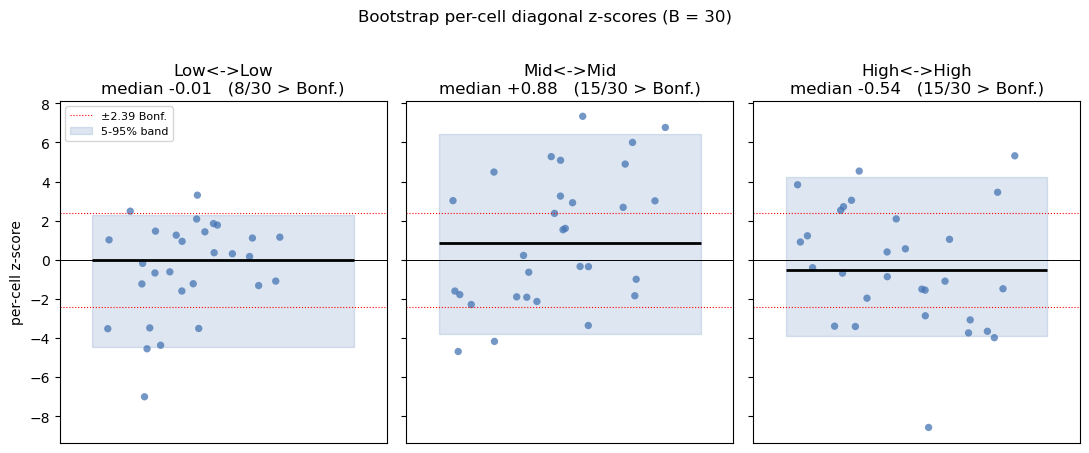

In [15]:
from skill_manifold.trial_null import subsample_robustness

def _egw_fn(Cj_i, Ce_i):
    r = entropic_gromov_wasserstein(Cj_i, Ce_i, epsilon=float(cfg['gw_epsilon']))
    return r.distance, _renorm(r.coupling)

B_RUNS = int(cfg.get('trial_null_n_subsamples', 30))
sr = subsample_robustness(
    feat_j=jr_df[j_cols].to_numpy(float),
    tiers_j_full=jr_df['tier'].to_numpy(),
    feat_e=er_df[e_cols].to_numpy(float),
    tiers_e_full=er_df['tier'].to_numpy(),
    tier_names=TIER_NAMES,
    entropic_gw_fn=_egw_fn,
    pairwise_rdm_fn=pairwise_cosine_rdm,
    n_per_tier=int(cfg['subsample_per_tier']),
    base_seed=int(cfg['seed']),
    n_subsamples=B_RUNS,
    n_perms=max(200, int(cfg['n_perms']) // 5),
)

# Table: per-cell z summaries vs trace p.
table = pd.DataFrame({
    'median z': sr.per_cell_median,
    'p05 z':    sr.per_cell_p05,
    'p95 z':    sr.per_cell_p95,
    'frac |z|>2.39': sr.frac_significant_per_cell_bonf,
}, index=[f'{n}<->{n}' for n in sr.tier_names])
print('Per-cell z distributions across', sr.n_runs, 'bootstrap resamples:')
display(table.style.format({
    'median z': '{:+.2f}', 'p05 z': '{:+.2f}', 'p95 z': '{:+.2f}',
    'frac |z|>2.39': '{:.2f}',
}))
print(f"Median diag_mass = {sr.observed_median:.4f} "
      f"(5-95% {sr.observed_p05:.4f}..{sr.observed_p95:.4f});  "
      f"trace p<0.05 in {int(sr.frac_p_lt_05 * sr.n_runs)}/{sr.n_runs}.")

# Three side-by-side strip plots, one per diagonal cell.
fig, axes = plt.subplots(1, 3, figsize=(11, 4.4), sharey=True)
rng_plot = np.random.default_rng(0)
for k, ax in enumerate(axes):
    xs = 0.4 + 0.2 * rng_plot.normal(size=sr.n_runs)
    zs = sr.per_cell_z[:, k]
    ax.scatter(xs, zs, s=28, alpha=0.75, color='#4575b4', edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':',
               linewidth=0.8, label=f'±{BONFERRONI_Z_THREE_CELLS:.2f} Bonf.')
    ax.axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':',
               linewidth=0.8)
    med = sr.per_cell_median[k]
    p05, p95 = sr.per_cell_p05[k], sr.per_cell_p95[k]
    ax.hlines(med, 0.1, 0.9, color='black', linewidth=2)
    ax.fill_betweenx([p05, p95], 0.1, 0.9, color='#4575b4', alpha=0.18,
                     label='5-95% band')
    frac = sr.frac_significant_per_cell_bonf[k]
    ax.set_xlim(0, 1); ax.set_xticks([])
    ax.set_title(
        f'{sr.tier_names[k]}<->{sr.tier_names[k]}\n'
        f'median {med:+.2f}   ({int(frac * sr.n_runs)}/{sr.n_runs} > Bonf.)')
    if k == 0:
        ax.set_ylabel('per-cell z-score')
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle(f'Bootstrap per-cell diagonal z-scores (B = {sr.n_runs})', y=1.02)
plt.tight_layout(); plt.show()

## Step 9d — Epsilon sensitivity (all-trials coupling, per-cell z)

`epsilon` sets the entropic regularization strength. If the headline `diag_mass` and the per-cell z's move a lot with ε, the finding is an artifact of the regularizer; if they're stable, the signal is independent of the regularizer (whatever its magnitude). We sweep ε ∈ {0.005, 0.01, 0.02, 0.05} on the all-trials coupling.

The y-axis of the diag_mass plot is clamped to **[0.28, 0.42]** so sub-1% wiggles around 1/3 aren't visually dramatized.

,diag_mass,GW_distance,z Low<->Low,z Mid<->Mid,z High<->High,row_sum_drift
epsilon,,,,,,
0.005000,0.3427,0.0589,+0.07,+1.23,+1.79,9.83e-13
0.010000,0.3378,0.0650,+0.25,+1.75,+0.29,8.19e-13
0.020000,0.3373,0.0705,+1.83,+2.35,+0.20,4.21e-13
0.050000,0.3349,0.0729,+2.68,+0.18,+4.68,3.47e-18


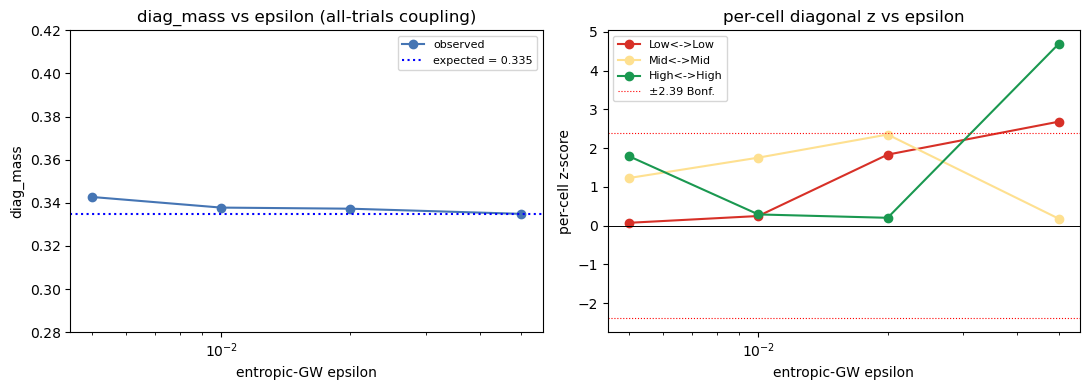

In [16]:
from skill_manifold.trial_null import epsilon_sensitivity

def _egw_fn_eps(Cj_i, Ce_i, eps):
    r = entropic_gromov_wasserstein(Cj_i, Ce_i, epsilon=float(eps))
    return r.distance, _renorm(r.coupling)

# Build the all-trials RDMs once for the sweep.
Cj_all = pairwise_cosine_rdm(jr_df[j_cols].to_numpy(float))
Ce_all = pairwise_cosine_rdm(er_df[e_cols].to_numpy(float))

eps_rows = epsilon_sensitivity(
    Cj=Cj_all, Ce=Ce_all,
    tiers_j=jr_df['tier'].to_numpy(),
    tiers_e=er_df['tier'].to_numpy(),
    tier_names=TIER_NAMES,
    entropic_gw_fn_eps=_egw_fn_eps,
    epsilons=(0.005, 0.01, 0.02, 0.05),
    n_perms=max(200, int(cfg['n_perms']) // 5),
    seed=int(cfg['seed']),
)
eps_df = pd.DataFrame([{
    'epsilon': r['epsilon'],
    'diag_mass': r['diag_mass'],
    'GW_distance': r['gw_distance'],
    **{f"z {n}<->{n}": float(z)
       for n, z in zip(TIER_NAMES, r['per_cell_z'])},
    'row_sum_drift': r['row_sum_drift'],
} for r in eps_rows]).set_index('epsilon')
display(eps_df.style.format({
    'diag_mass': '{:.4f}', 'GW_distance': '{:.4f}',
    'z Low<->Low': '{:+.2f}', 'z Mid<->Mid': '{:+.2f}', 'z High<->High': '{:+.2f}',
    'row_sum_drift': '{:.2e}',
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

xs = [r['epsilon'] for r in eps_rows]
ys = [r['diag_mass'] for r in eps_rows]
axes[0].plot(xs, ys, marker='o', color='#4575b4', label='observed')
axes[0].axhline(primary['expected_trace_under_null'],
                color='blue', linestyle=':',
                label=f"expected = {primary['expected_trace_under_null']:.3f}")
axes[0].set_xscale('log'); axes[0].set_xlabel('entropic-GW epsilon')
axes[0].set_ylabel('diag_mass')
axes[0].set_ylim(0.28, 0.42)   # tightened so sub-1% wiggles don't dramatize
axes[0].set_title('diag_mass vs epsilon (all-trials coupling)')
axes[0].legend(fontsize=8)

per_cell_by_eps = np.asarray([r['per_cell_z'] for r in eps_rows])
colors = {'Low': '#d73027', 'Mid': '#fee090', 'High': '#1a9850'}
for k, name in enumerate(TIER_NAMES):
    axes[1].plot(xs, per_cell_by_eps[:, k], marker='o',
                 color=colors[name], label=f'{name}<->{name}')
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':',
                linewidth=0.8, label=f'±{BONFERRONI_Z_THREE_CELLS:.2f} Bonf.')
axes[1].axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':',
                linewidth=0.8)
axes[1].set_xscale('log'); axes[1].set_xlabel('entropic-GW epsilon')
axes[1].set_ylabel('per-cell z-score')
axes[1].set_title('per-cell diagonal z vs epsilon')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## Step 9e — Balanced-subsample sensitivity (demoted from primary)

The historic balanced-100-per-tier analysis is retained here as a *sensitivity check*. It upsamples each JIGSAWS trial with replacement, so on the 103-trial JIGSAWS side each unique trial appears ~3× in the 300-sample balanced draw. That artificially sharpens the coupling and tends to inflate per-cell z-scores relative to the all-trials primary.

The goal of this cell is to show that the direction (sign of each per-cell z) is similar between the two, even though the magnitudes diverge.

In [17]:
from skill_manifold.trial_null import trial_level_block_null

# Use the balanced 100-per-tier tj/te/egw computed in Step 9 above.
T_bal = _renorm(egw.coupling)
balanced = trial_level_block_null(T_bal, tj, te, TIER_NAMES,
                                  n_perms=int(cfg['n_perms']),
                                  seed=int(cfg['seed']))

# Side-by-side comparison of primary (all-trials) vs balanced subsample.
comp = pd.DataFrame({
    'all-trials (primary)': [
        float(primary['observed']),
        float(primary['expected_trace_under_null']),
        float(primary['p_value']),
        float(primary['z_score']),
        *[float(z) for z in primary['per_cell_z']],
    ],
    'balanced 100/tier (sensitivity)': [
        float(balanced['observed']),
        1.0 / 3.0,
        float(balanced['p_value']),
        float(balanced['z_score']),
        *[float(z) for z in balanced['per_cell_z']],
    ],
}, index=['diag_mass observed', 'expected trace', 'trace p-value', 'trace z',
          'z Low<->Low', 'z Mid<->Mid', 'z High<->High'])
display(comp.style.format('{:+.3f}'))

signs_agree = all(
    np.sign(a) == np.sign(b) or abs(a) < 0.3 or abs(b) < 0.3
    for a, b in zip(primary['per_cell_z'], balanced['per_cell_z'])
)
print(f"Per-cell signs agree across primary and balanced? {signs_agree}")

,all-trials (primary),balanced 100/tier (sensitivity)
diag_mass observed,+0.338,+0.334
expected trace,+0.335,+0.333
trace p-value,+0.153,+0.307
trace z,+1.007,+0.455
z Low<->Low,+0.141,-0.566
z Mid<->Mid,+1.759,+3.030
z High<->High,+0.203,-1.603


Per-cell signs agree across primary and balanced? True


## Step 9f — Fixed-cutoff sensitivity (binning artifact vs real alignment)

Tertile binning makes the Mid tier exactly 1/3 of each dataset by construction. The Mid tertile is typically a *narrow* band in score space, so its feature-space density is higher than Low or High. That density concentration can produce Mid-only alignment **without any shared skill structure** — a binning artifact.

To disambiguate, we swap to **hard cutoffs** with absolute meaning:

- JIGSAWS: Low `grs_total < 16`, Mid `16–22`, High `> 22`
- Mimic:   Low `performance < 70`, Mid `70–85`, High `> 85`

The Mid tertile-z was the headline earlier (~+3 in v1, +1.76 here on the all-trials primary). If the fixed-cutoff Mid-z stays strongly positive, the alignment is probably real skill, not density compression. If it collapses to ~0, the signal was binning-driven.

JIGSAWS tier counts (fixed cutoffs <16/16-22/>22): {'Low': 49, 'Mid': 40, 'High': 14}
Mimic   tier counts (fixed cutoffs <70/70-85/>85): {'Low': 147, 'Mid': 163, 'High': 200}

observed diag_mass   = 0.3247
expected under null  = 0.3145
trace p / z          = 0.0030 / +3.734
per-cell z-scores (|z| > 2.39 marked **):
  ** Low<->Low: z = +3.29
  ** Mid<->Mid: z = +2.97
     High<->High: z = +1.37

Mid<->Mid z -- tertile +1.76, fixed +2.97 => Survives the binning change.


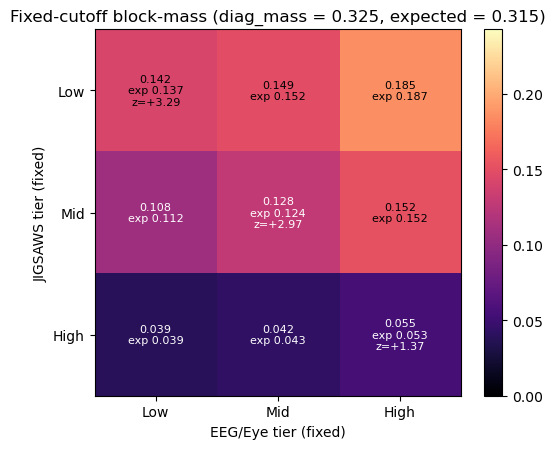

In [18]:
from skill_manifold.binning import assign_fixed_tier

jt_fixed = assign_fixed_tier(jr_df['grs_total'].to_numpy(), 16, 22)
et_fixed = assign_fixed_tier(er_df['performance'].to_numpy(), 70, 85)

jcts = pd.Series(jt_fixed).value_counts().reindex(TIER_NAMES)
ects = pd.Series(et_fixed).value_counts().reindex(TIER_NAMES)
print(f'JIGSAWS tier counts (fixed cutoffs <16/16-22/>22): {jcts.to_dict()}')
print(f'Mimic   tier counts (fixed cutoffs <70/70-85/>85): {ects.to_dict()}')

fixed = trial_level_block_null_all_trials(
    features_j=jr_df[j_cols].to_numpy(float),
    tiers_j=jt_fixed,
    features_e=er_df[e_cols].to_numpy(float),
    tiers_e=et_fixed,
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=int(cfg['n_perms']),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_with_eps,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)

print()
print(f"observed diag_mass   = {fixed['observed']:.4f}")
print(f"expected under null  = {fixed['expected_trace_under_null']:.4f}")
print(f"trace p / z          = {fixed['p_value']:.4f} / {fixed['z_score']:+.3f}")
print('per-cell z-scores (|z| > 2.39 marked **):')
for n, z in zip(fixed['tier_names'], fixed['per_cell_z']):
    flag = '**' if abs(z) > BONFERRONI_Z_THREE_CELLS else '  '
    print(f"  {flag} {n}<->{n}: z = {z:+.2f}")

# Single-row comparison table: tertile Mid z vs fixed-cutoff Mid z.
mid_idx = list(primary['tier_names']).index('Mid')
tertile_mid_z = float(primary['per_cell_z'][mid_idx])
fixed_mid_z = float(fixed['per_cell_z'][mid_idx])
diff_label = ('Survives' if fixed_mid_z > 2.0
              else ('Collapses' if abs(fixed_mid_z) < 1.0 else 'Shifts'))
print()
print(f'Mid<->Mid z -- tertile {tertile_mid_z:+.2f}, fixed {fixed_mid_z:+.2f} '
      f'=> {diff_label} the binning change.')

# Heatmap of the fixed-cutoff block mass with observed/expected per cell.
Bf = np.asarray(fixed['block_mass']); Bf_exp = np.asarray(fixed['expected_block_mass'])
fig, ax = plt.subplots(figsize=(5.5, 4.6))
vmax = max(Bf.max(), float(Bf_exp.max()) * 1.3)
im = ax.imshow(Bf, cmap='magma', vmin=0, vmax=vmax)
ax.set_xticks(range(3), TIER_NAMES); ax.set_yticks(range(3), TIER_NAMES)
ax.set_xlabel('EEG/Eye tier (fixed)'); ax.set_ylabel('JIGSAWS tier (fixed)')
for i in range(3):
    for j in range(3):
        label = f'{Bf[i, j]:.3f}\nexp {Bf_exp[i, j]:.3f}'
        if i == j:
            label += f'\nz={fixed["per_cell_z"][i]:+.2f}'
        ax.text(j, i, label, ha='center', va='center',
                color='white' if Bf[i, j] < vmax * 0.55 else 'black', fontsize=8)
ax.set_title(
    f"Fixed-cutoff block-mass (diag_mass = {fixed['observed']:.3f}, "
    f"expected = {fixed['expected_trace_under_null']:.3f})")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Step 9g — Fixed-cutoff bootstrap robustness (stratified)

Step 9f's fixed-cutoff result came from a **single coupling**. To decide whether those per-cell z-scores are real or just a lucky draw, we bootstrap — but *not* by drawing 100 per tier. With only 14 JIGSAWS High-tier trials under the fixed cutoffs, 100-per-tier resampling would upsample each ~7x and fabricate precision.

**Stratified bootstrap (the right construction here).** For each of `B = 30` resamples:

- For each JIGSAWS tier `a`, draw `n_j_a` trials with replacement from the observed pool (so tier counts stay at 49/40/14 exactly).
- Same on the Mimic side (147/163/200).
- Run `trial_level_block_null_all_trials` on the resampled (features, labels) pair and record trace p + per-cell z.

Key statistics:

- **Median per-cell z** — center of the distribution.
- **`frac(z > 0)`** — sign consistency. If only ~60 % of bootstraps give the same sign as the single-shot, the finding is fragile even if the magnitude looks OK.
- **`frac(|z| > 2.39)`** — Bonferroni-level significance rate.

Go/no-go rule:

- **GO**: Low<->Low *and* Mid<->Mid both have median z > +2 AND `frac(z > 0) > 0.90` AND `frac(|z| > 2.39) > 0.50`.
- **CAUTION**: Low or Mid median z > +2 but `frac(z > 0) < 0.90` — robust magnitude, unstable sign.
- **NO-GO**: bands on Low and Mid both span zero.

The tertile binning is run through the same stratified bootstrap for an apples-to-apples comparison.

---- Fixed-cutoff stratified bootstrap (B = 30, degenerate = 0) ----
  tier_counts J / E = [49, 40, 14] / [147, 163, 200]
  frac trace p < 0.05 = 0.47


,median z,p05 z,p95 z,frac |z|>2.39,frac z>0
cell,,,,,
Low<->Low,+0.97,-3.40,+5.96,0.40,0.67
Mid<->Mid,+1.37,-2.25,+6.18,0.50,0.70
High<->High,-0.10,-3.31,+5.54,0.40,0.50



---- Tertile stratified bootstrap (apples-to-apples) (B = 30, degenerate = 0) ----
  tier_counts J / E = [38, 36, 29] / [171, 180, 159]
  frac trace p < 0.05 = 0.33


,median z,p05 z,p95 z,frac |z|>2.39,frac z>0
cell,,,,,
Low<->Low,+0.09,-5.39,+5.59,0.57,0.50
Mid<->Mid,-0.43,-4.96,+6.12,0.43,0.47
High<->High,+0.79,-4.25,+4.01,0.33,0.60



Fixed-cutoff verdict: NO-GO  (Low med +0.97, Mid med +1.37; frac(z>0) Low 0.67, Mid 0.70)
Tertile verdict:      NO-GO  (Low med +0.09, Mid med -0.43; frac(z>0) Low 0.50, Mid 0.47)


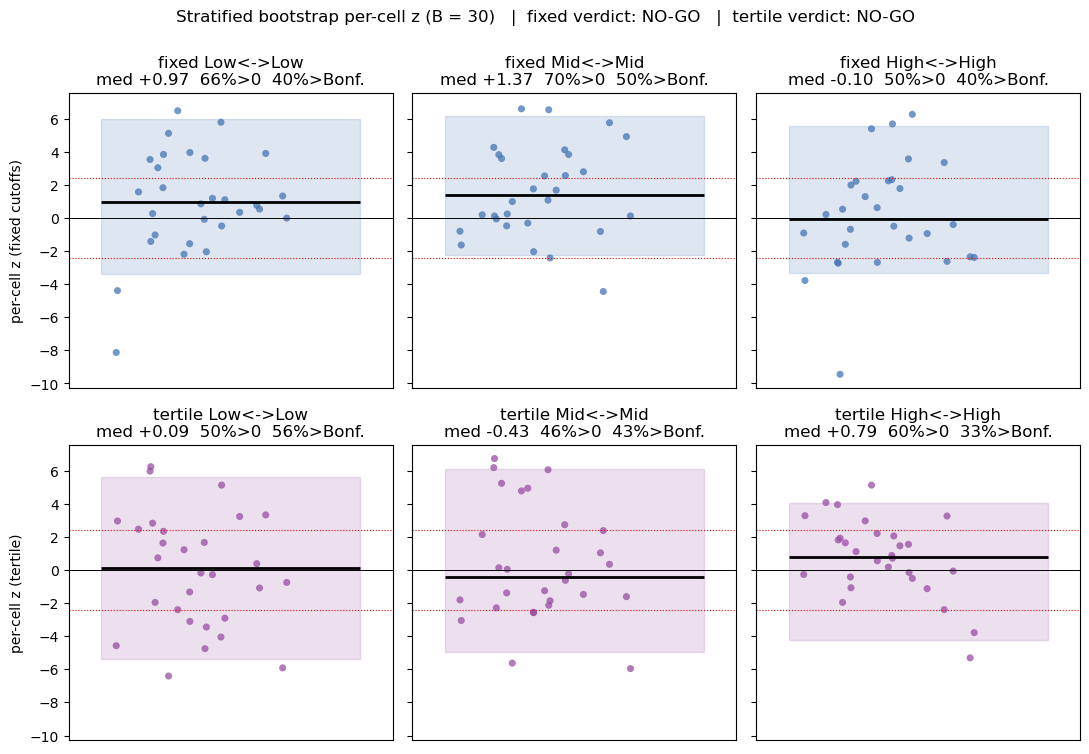

In [19]:
from skill_manifold.trial_null import (
    subsample_robustness_stratified, stratified_bootstrap_verdict,
)

def _egw_stratified(Cj_i, Ce_i, eps):
    r = entropic_gromov_wasserstein(Cj_i, Ce_i, epsilon=float(eps))
    T = np.asarray(r.coupling, float)
    if max(np.max(np.abs(T.sum(axis=1) - 1.0 / T.shape[0])),
           np.max(np.abs(T.sum(axis=0) - 1.0 / T.shape[1]))) > 1e-9:
        T = _renorm(T)
    return float(r.distance), T

# Stratified bootstrap on the fixed-cutoff labels from Step 9f.
fb = subsample_robustness_stratified(
    features_j=jr_df[j_cols].to_numpy(float),
    tiers_j=jt_fixed,
    features_e=er_df[e_cols].to_numpy(float),
    tiers_e=et_fixed,
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=max(200, int(cfg['n_perms']) // 5),
    n_bootstraps=int(cfg.get('trial_null_n_subsamples', 30)),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_stratified,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)
fb_verdict = stratified_bootstrap_verdict(fb, TIER_NAMES)

# Apples-to-apples: same method on the tertile labels.
tb = subsample_robustness_stratified(
    features_j=jr_df[j_cols].to_numpy(float),
    tiers_j=jr_df['tier'].to_numpy(),
    features_e=er_df[e_cols].to_numpy(float),
    tiers_e=er_df['tier'].to_numpy(),
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=max(200, int(cfg['n_perms']) // 5),
    n_bootstraps=int(cfg.get('trial_null_n_subsamples', 30)),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_stratified,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)
tb_verdict = stratified_bootstrap_verdict(tb, TIER_NAMES)

def _summary_table(result, tier_names, label):
    rows = []
    for k, name in enumerate(tier_names):
        s = result['summary'][f'per_cell_z_{name}']
        rows.append({
            'cell': f'{name}<->{name}',
            'median z': s['median'],
            'p05 z': s['p05'],
            'p95 z': s['p95'],
            'frac |z|>2.39': float(result['frac_per_cell_bonf'][k]),
            'frac z>0': float(result['frac_per_cell_positive'][k]),
        })
    df = pd.DataFrame(rows).set_index('cell')
    print(f'---- {label} (B = {result["n_bootstraps"]}, degenerate = {result["n_degenerate"]}) ----')
    print(f'  tier_counts J / E = {list(result["tier_counts_j"])} / {list(result["tier_counts_e"])}')
    print(f'  frac trace p < 0.05 = {result["frac_significant_trace"]:.2f}')
    display(df.style.format({
        'median z': '{:+.2f}', 'p05 z': '{:+.2f}', 'p95 z': '{:+.2f}',
        'frac |z|>2.39': '{:.2f}', 'frac z>0': '{:.2f}',
    }))
    return df

fb_df = _summary_table(fb, TIER_NAMES, 'Fixed-cutoff stratified bootstrap')
print()
tb_df = _summary_table(tb, TIER_NAMES, 'Tertile stratified bootstrap (apples-to-apples)')

print()
print(f'Fixed-cutoff verdict: {fb_verdict["verdict"]}  '
      f'(Low med {fb_verdict["low_median"]:+.2f}, Mid med {fb_verdict["mid_median"]:+.2f}; '
      f'frac(z>0) Low {fb_verdict["frac_positive_low"]:.2f}, Mid {fb_verdict["frac_positive_mid"]:.2f})')
print(f'Tertile verdict:      {tb_verdict["verdict"]}  '
      f'(Low med {tb_verdict["low_median"]:+.2f}, Mid med {tb_verdict["mid_median"]:+.2f}; '
      f'frac(z>0) Low {tb_verdict["frac_positive_low"]:.2f}, Mid {tb_verdict["frac_positive_mid"]:.2f})')

# Plot: six strip plots, three per binning x three cells.
def _strip(ax, zs, name, frac_bonf, frac_pos, bg='#4575b4'):
    rng_plot = np.random.default_rng(0)
    xs = 0.4 + 0.2 * rng_plot.normal(size=zs.shape[0])
    ax.scatter(xs, zs, s=26, alpha=0.75, color=bg, edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    ax.axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    med = float(np.median(zs)); p05 = float(np.quantile(zs, 0.05)); p95 = float(np.quantile(zs, 0.95))
    ax.hlines(med, 0.1, 0.9, color='black', linewidth=2)
    ax.fill_betweenx([p05, p95], 0.1, 0.9, color=bg, alpha=0.18)
    ax.set_xlim(0, 1); ax.set_xticks([])
    ax.set_title(f'{name}\nmed {med:+.2f}  {int(frac_pos*100)}%>0  {int(frac_bonf*100)}%>Bonf.')

fig, axes = plt.subplots(2, 3, figsize=(11, 7.5), sharey=True)
for k, n in enumerate(TIER_NAMES):
    _strip(axes[0, k], fb['per_cell_z'][:, k], f'fixed {n}<->{n}',
           fb['frac_per_cell_bonf'][k], fb['frac_per_cell_positive'][k], '#4575b4')
    _strip(axes[1, k], tb['per_cell_z'][:, k], f'tertile {n}<->{n}',
           tb['frac_per_cell_bonf'][k], tb['frac_per_cell_positive'][k], '#984ea3')
axes[0, 0].set_ylabel('per-cell z (fixed cutoffs)')
axes[1, 0].set_ylabel('per-cell z (tertile)')
fig.suptitle(
    f'Stratified bootstrap per-cell z (B = {fb["n_bootstraps"]})   |  '
    f'fixed verdict: {fb_verdict["verdict"]}   |  '
    f'tertile verdict: {tb_verdict["verdict"]}', y=1.00)
plt.tight_layout(); plt.show()

## Step 10 — Mimic-side modality split

Each of the three Mimic-side data streams (EEG baseline, EEG predictive-coding, eye summary) is run in isolation against the full combined JIGSAWS manifold. Compare per-modality per-cell z distributions under the stratified bootstrap (fixed-cutoff binning primary, tertile as sensitivity).

This answers **"which upstream Mimic modality carries the cross-dataset alignment (if any)?"**

- If one modality is GO and the others are NO-GO/CAUTION → the signal localizes to that modality.
- If several are GO with similar distributions → signal is shared across modalities; likely a common trial-level property.
- If all three are NO-GO → the Step 9f/9g combined-modality signal does not localize; consistent with a weak-or-absent population effect that looked real in a single coupling.

In [20]:
from skill_manifold.features_eeg_eye import mimic_modality_columns
from skill_manifold.trial_null import modality_split_analysis

def _egw_mod(Cj_i, Ce_i, eps):
    r = entropic_gromov_wasserstein(Cj_i, Ce_i, epsilon=float(eps))
    T = np.asarray(r.coupling, float)
    if max(np.max(np.abs(T.sum(axis=1) - 1.0 / T.shape[0])),
           np.max(np.abs(T.sum(axis=0) - 1.0 / T.shape[1]))) > 1e-9:
        T = _renorm(T)
    return float(r.distance), T

mod_cols = mimic_modality_columns()
print('modality dims:', {k: len(v) for k, v in mod_cols.items()})

mod_results = modality_split_analysis(
    features_j=jr_df[j_cols].to_numpy(float),
    tiers_j_tertile=jr_df['tier'].to_numpy(),
    tiers_j_fixed=jt_fixed,
    features_e_full=er_df[e_cols].to_numpy(float),
    e_cols_full=e_cols,
    modality_columns=mod_cols,
    tiers_e_tertile=er_df['tier'].to_numpy(),
    tiers_e_fixed=et_fixed,
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=int(cfg.get('modality_split_n_perms', cfg['n_perms'])),
    n_bootstraps=int(cfg.get('modality_split_n_bootstraps', cfg.get('trial_null_n_subsamples', 30))),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_mod,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)

# Build a summary DataFrame: one row per (modality, binning, cell).
rows = []
for mod in mod_cols.keys():
    for binning in ('fixed', 'tertile'):
        pr = mod_results[mod][binning]['primary']
        bs = mod_results[mod][binning]['bootstrap']
        v = mod_results[mod][binning]['verdict']['verdict']
        for k, name in enumerate(TIER_NAMES):
            s = bs['summary'][f'per_cell_z_{name}']
            rows.append({
                'modality': mod,
                'binning': binning,
                'cell': f'{name}<->{name}',
                'trace_z': float(pr['z_score']),
                'trace_p': float(pr['p_value']),
                'z_primary': float(pr['per_cell_z'][k]),
                'z_median': s['median'],
                'z_5pct':   s['p05'],
                'z_95pct':  s['p95'],
                'frac_z>0': float(bs['frac_per_cell_positive'][k]),
                'frac_|z|>2.39': float(bs['frac_per_cell_bonf'][k]),
                'verdict': v,
            })
summary_df = pd.DataFrame(rows)
display(summary_df.style.format({
    'trace_z': '{:+.2f}', 'trace_p': '{:.4f}',
    'z_primary': '{:+.2f}', 'z_median': '{:+.2f}',
    'z_5pct': '{:+.2f}', 'z_95pct': '{:+.2f}',
    'frac_z>0': '{:.2f}', 'frac_|z|>2.39': '{:.2f}',
}))

print()
print('Verdicts (one per modality x binning):')
for mod in mod_cols.keys():
    for binning in ('fixed', 'tertile'):
        v = mod_results[mod][binning]['verdict']
        pr = mod_results[mod][binning]['primary']
        print(f'  {mod:25s} {binning:8s} primary trace_z={pr["z_score"]:+.2f} '
              f'p={pr["p_value"]:.4f} | verdict: {v["verdict"]} '
              f'(Low med {v["low_median"]:+.2f}, Mid med {v["mid_median"]:+.2f}, '
              f'sign>0 L/M {v["frac_positive_low"]:.2f}/{v["frac_positive_mid"]:.2f})')

modality dims: {'eeg_baseline': 64, 'eeg_predictive_coding': 64, 'eye': 18}


,modality,binning,cell,trace_z,trace_p,z_primary,z_median,z_5pct,z_95pct,frac_z>0,frac_|z|>2.39,verdict
0,eeg_baseline,fixed,Low<->Low,+1.68,0.0324,+1.74,+0.47,-3.71,+3.86,0.50,0.50,NO-GO
1,eeg_baseline,fixed,Mid<->Mid,+1.68,0.0324,+1.64,+0.15,-3.27,+2.45,0.62,0.25,NO-GO
2,eeg_baseline,fixed,High<->High,+1.68,0.0324,-0.24,+0.69,-2.79,+3.52,0.88,0.38,NO-GO
3,eeg_baseline,tertile,Low<->Low,+0.12,0.4389,+0.97,+0.40,-2.65,+3.47,0.75,0.38,NO-GO
4,eeg_baseline,tertile,Mid<->Mid,+0.12,0.4389,-0.11,+0.60,-2.25,+3.71,0.50,0.50,NO-GO
5,eeg_baseline,tertile,High<->High,+0.12,0.4389,-0.65,+0.53,-4.00,+3.66,0.62,0.38,NO-GO
6,eeg_predictive_coding,fixed,Low<->Low,+3.48,0.0025,+3.01,+0.26,-4.84,+3.80,0.50,0.50,NO-GO
7,eeg_predictive_coding,fixed,Mid<->Mid,+3.48,0.0025,+2.32,+0.01,-3.06,+3.06,0.50,0.38,NO-GO
8,eeg_predictive_coding,fixed,High<->High,+3.48,0.0025,+1.80,+1.56,-2.30,+3.72,0.75,0.25,NO-GO
9,eeg_predictive_coding,tertile,Low<->Low,+3.80,0.0025,+2.48,+0.15,-5.38,+3.04,0.50,0.38,NO-GO



Verdicts (one per modality x binning):
  eeg_baseline              fixed    primary trace_z=+1.68 p=0.0324 | verdict: NO-GO (Low med +0.47, Mid med +0.15, sign>0 L/M 0.50/0.62)
  eeg_baseline              tertile  primary trace_z=+0.12 p=0.4389 | verdict: NO-GO (Low med +0.40, Mid med +0.60, sign>0 L/M 0.75/0.50)
  eeg_predictive_coding     fixed    primary trace_z=+3.48 p=0.0025 | verdict: NO-GO (Low med +0.26, Mid med +0.01, sign>0 L/M 0.50/0.50)
  eeg_predictive_coding     tertile  primary trace_z=+3.80 p=0.0025 | verdict: NO-GO (Low med +0.15, Mid med +1.96, sign>0 L/M 0.50/0.88)
  eye                       fixed    primary trace_z=+0.70 p=0.2569 | verdict: NO-GO (Low med +0.01, Mid med -0.18, sign>0 L/M 0.50/0.50)
  eye                       tertile  primary trace_z=-2.81 p=0.9950 | verdict: NO-GO (Low med -1.42, Mid med +0.00, sign>0 L/M 0.25/0.50)


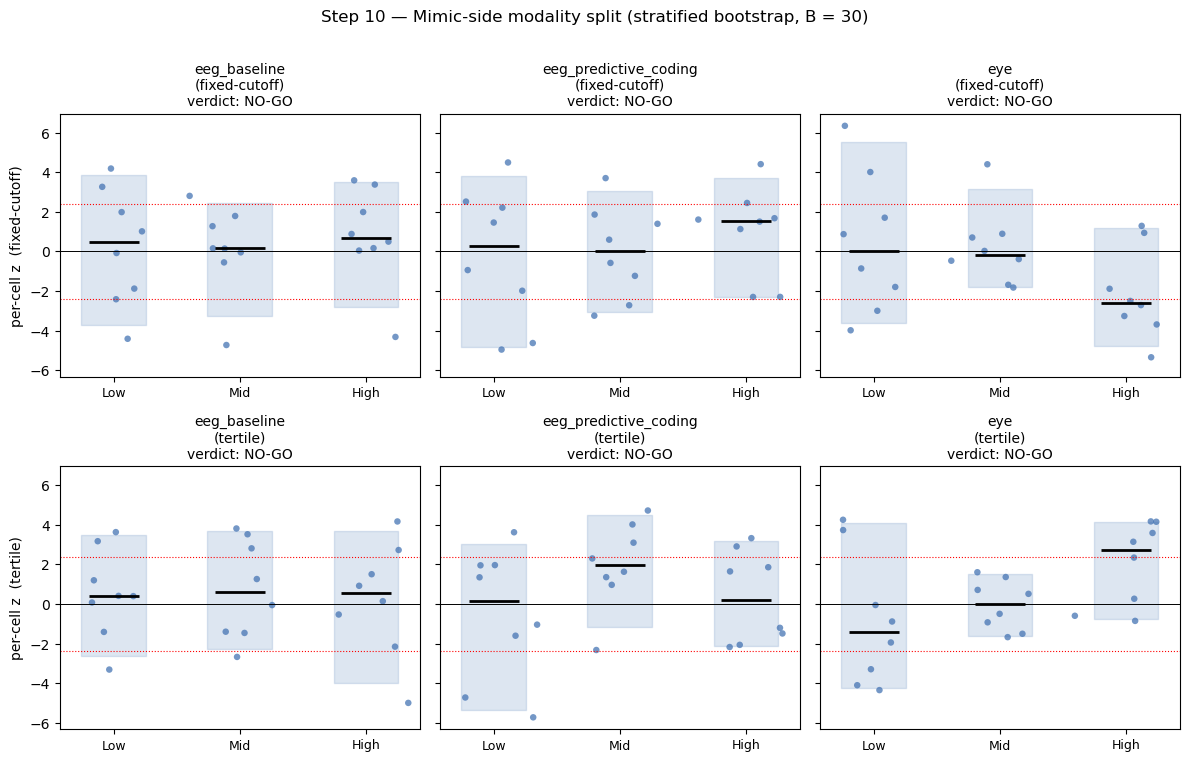

In [21]:
# Comparison violin/strip plot: 2 rows (fixed/tertile) x 3 columns (modalities),
# three scatter strips per panel (Low/Mid/High). Shared y-axis.
mods = list(mod_cols.keys())
fig, axes = plt.subplots(2, len(mods), figsize=(4 * len(mods), 7.5), sharey=True)
rng_plot = np.random.default_rng(0)

def _panel(ax, pcz, verdict_label, title):
    for k, name in enumerate(TIER_NAMES):
        xs = 0.15 + k * 0.35 + 0.06 * rng_plot.normal(size=pcz.shape[0])
        ax.scatter(xs, pcz[:, k], s=22, alpha=0.75,
                   color='#4575b4', edgecolors='none')
        med = float(np.median(pcz[:, k]))
        p05 = float(np.quantile(pcz[:, k], 0.05))
        p95 = float(np.quantile(pcz[:, k], 0.95))
        ax.hlines(med, 0.15 + k * 0.35 - 0.07, 0.15 + k * 0.35 + 0.07,
                  color='black', linewidth=2)
        ax.fill_betweenx([p05, p95],
                         0.15 + k * 0.35 - 0.09, 0.15 + k * 0.35 + 0.09,
                         color='#4575b4', alpha=0.18)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    ax.axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    ax.set_xlim(0, 1)
    ax.set_xticks([0.15 + k * 0.35 for k in range(len(TIER_NAMES))],
                  [n for n in TIER_NAMES], fontsize=9)
    ax.set_title(f'{title}\nverdict: {verdict_label}', fontsize=10)

for j, mod in enumerate(mods):
    fb = mod_results[mod]['fixed']['bootstrap']
    tb = mod_results[mod]['tertile']['bootstrap']
    _panel(axes[0, j], fb['per_cell_z'],
           mod_results[mod]['fixed']['verdict']['verdict'],
           f'{mod}\n(fixed-cutoff)')
    _panel(axes[1, j], tb['per_cell_z'],
           mod_results[mod]['tertile']['verdict']['verdict'],
           f'{mod}\n(tertile)')

axes[0, 0].set_ylabel('per-cell z  (fixed-cutoff)')
axes[1, 0].set_ylabel('per-cell z  (tertile)')
fig.suptitle(f'Step 10 — Mimic-side modality split (stratified bootstrap, B = {int(cfg.get("trial_null_n_subsamples", 30))})',
             y=1.01)
plt.tight_layout(); plt.show()

## Step 10 — diagnostic P1: EEG baseline/pc correlation

The baseline and predictive-coding EEG encoders consume the *same* Phase 1 windows per trial, so they are **not independent evidence streams**. If the per-cell z-scores for `eeg_baseline` and `eeg_predictive_coding` differ, we need to know whether that difference reflects a meaningful encoding contrast or just noise on top of a shared signal. This cell reports the per-trial Pearson correlation between the two mean-pooled embeddings and treats the magnitude as a caveat for Step 10's verdicts.

per-trial r (baseline-mean vs pc-mean): median +0.010, |r| median 0.084, 5-95% [-0.20, +0.19], fraction |r|>0.5 = 0.00, n_trials = 510


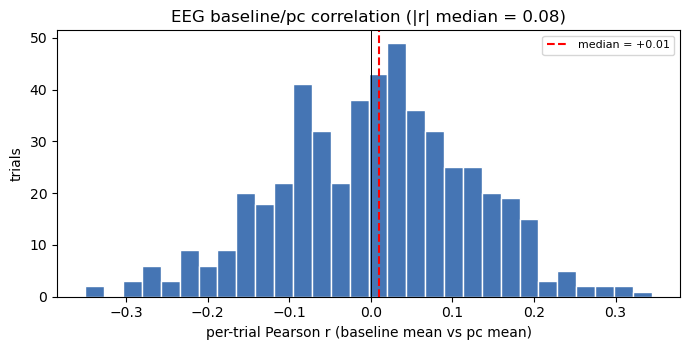


CAVEAT for Step 10 verdicts:
  The two EEG encoders share the same Phase 1 input.
  Treat per-modality z-score differences as ENCODING-CONTRAST indicators,
  not as statistically independent tests of skill alignment.


In [22]:
from skill_manifold.trial_null import eeg_baseline_pc_correlation

corr = eeg_baseline_pc_correlation(
    features_e_full=er_df[e_cols].to_numpy(float),
    baseline_cols=mod_cols['eeg_baseline'],
    pc_cols=mod_cols['eeg_predictive_coding'],
    e_cols_full=e_cols,
)
print(f'per-trial r (baseline-mean vs pc-mean): '
      f'median {corr["median"]:+.3f}, |r| median {corr["median_abs"]:.3f}, '
      f'5-95% [{corr["p05"]:+.2f}, {corr["p95"]:+.2f}], '
      f'fraction |r|>0.5 = {corr["frac_abs_gt_0p5"]:.2f}, '
      f'n_trials = {corr["n_trials"]}')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(corr['per_trial_pearson_r'], bins=30,
        color='#4575b4', edgecolor='white')
ax.axvline(corr['median'], color='red', linestyle='--',
           label=f"median = {corr['median']:+.2f}")
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('per-trial Pearson r (baseline mean vs pc mean)')
ax.set_ylabel('trials')
ax.set_title(f"EEG baseline/pc correlation (|r| median = {corr['median_abs']:.2f})")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print()
print('CAVEAT for Step 10 verdicts:')
print('  The two EEG encoders share the same Phase 1 input.')
print('  Treat per-modality z-score differences as ENCODING-CONTRAST indicators,')
print('  not as statistically independent tests of skill alignment.')

## Step 10 — diagnostic P3: Pooled-128 EEG random-split null

If the baseline-vs-pc single-shot trace-z difference is a real encoding contrast, that signed delta should be **larger** than most random 64+64 splits of the combined 128 EEG dims. If the observed delta sits inside the random-split distribution, the split is statistically uninformative — any 64-column draw gives roughly the same per-cell z.

observed baseline - pc trace_z delta = -1.792
random 64+64 split null (n=20): median +0.271, 5-95%% [-3.02, +2.99]
two-sided p (random-split null): 0.429


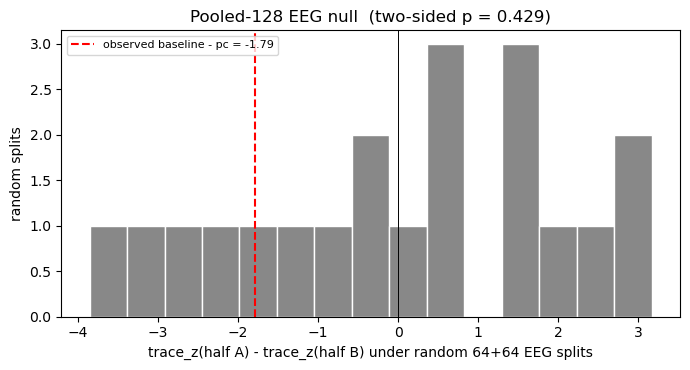

In [23]:
from skill_manifold.trial_null import pooled_eeg_random_split_null

pooled = pooled_eeg_random_split_null(
    features_j=jr_df[j_cols].to_numpy(float),
    tiers_j=jt_fixed,
    features_e_full=er_df[e_cols].to_numpy(float),
    e_cols_full=e_cols,
    eeg_combined_cols=mod_cols['eeg_baseline'] + mod_cols['eeg_predictive_coding'],
    half_size=len(mod_cols['eeg_baseline']),
    tiers_e=et_fixed,
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=200, n_random_splits=20, seed=int(cfg['seed']),
    entropic_gw_fn=_egw_mod,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)

fb_zs = {m: mod_results[m]['fixed']['primary']['z_score']
         for m in ('eeg_baseline', 'eeg_predictive_coding')}
observed_delta = fb_zs['eeg_baseline'] - fb_zs['eeg_predictive_coding']
null_delta = pooled['delta_distribution']
p_two = (1 + (np.abs(null_delta) >= abs(observed_delta)).sum()) / (1 + len(null_delta))
print(f'observed baseline - pc trace_z delta = {observed_delta:+.3f}')
print(f'random 64+64 split null (n={len(null_delta)}): '
      f'median {np.median(null_delta):+.3f}, '
      f'5-95%% [{np.quantile(null_delta, 0.05):+.2f}, '
      f'{np.quantile(null_delta, 0.95):+.2f}]')
print(f'two-sided p (random-split null): {p_two:.3f}')

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(null_delta, bins=15, color='#888', edgecolor='white')
ax.axvline(observed_delta, color='red', linestyle='--',
           label=f'observed baseline - pc = {observed_delta:+.2f}')
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('trace_z(half A) - trace_z(half B) under random 64+64 EEG splits')
ax.set_ylabel('random splits')
ax.set_title(f'Pooled-128 EEG null  (two-sided p = {p_two:.3f})')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Step 10 — diagnostic P4: Eye-only coupling matrix

The eye modality is 18-dimensional vs 64 for each EEG stream. Low-dim cosine-distance matrices can become degenerate (many near-duplicate rows), which makes entropic GW unstable and could explain the large negative eye-only trace z we saw under tertile binning. This cell reports:

- rank of the eye-only cosine-distance matrix
- count of near-duplicate row pairs (cos-distance < 1e-4)
- pre-renorm coupling marginal drift

If rank < N or near-duplicate fraction is non-trivial, the eye verdict should be read as an artifact of geometry, not as an anti-aligned skill signal.

In [24]:
from skill_manifold.trial_null import coupling_matrix_diagnostics

eye_cols_sub = mod_cols['eye']
col_to_idx = {c: i for i, c in enumerate(e_cols)}
eye_idx = np.array([col_to_idx[c] for c in eye_cols_sub], dtype=np.int64)
eye_feat = er_df[e_cols].to_numpy(float)[:, eye_idx]
Cj_eye = pairwise_cosine_rdm(jr_df[j_cols].to_numpy(float))
Ce_eye = pairwise_cosine_rdm(eye_feat)
_d, T_eye = _egw_mod(Cj_eye, Ce_eye, float(cfg['gw_epsilon']))
eye_diag = coupling_matrix_diagnostics(T_eye, eye_feat)

print(f'eye-only cosine-distance matrix rank = {eye_diag["distance_rank"]} '
      f'(out of {eye_diag["n_trials"]} trials)')
print(f'near-duplicate row pairs (cos-distance < 1e-4): '
      f'{eye_diag["near_duplicate_pairs"]}/{eye_diag["total_pairs"]} '
      f'({eye_diag["near_duplicate_fraction"]:.2%})')
print(f'coupling marginal drift: row {eye_diag["coupling_row_drift"]:.2e}, '
      f'col {eye_diag["coupling_col_drift"]:.2e}')
print(f'eye feature dim = {eye_diag["n_features"]}')

eye-only cosine-distance matrix rank = 16 (out of 510 trials)
near-duplicate row pairs (cos-distance < 1e-4): 0/129795 (0.00%)
coupling marginal drift: row 3.47e-18, col 5.65e-11
eye feature dim = 18


## Step 11 — JIGSAWS-side modality split (P2)

Step 10 asked "which **Mimic** stream carries the signal?" Step 11 flips the roles: Mimic stays as the full 146-dim combined manifold, and the JIGSAWS 39-dim vector is partitioned into **gestures** (14 dims, the gesture histogram) and **kinematics** (24 dims, per-arm Slave kinematics). Duration (1 dim) is omitted because cosine distance on 1-d vectors is degenerate.

This tells us whether any Mimic alignment that does appear is driven by gestural structure, kinematic structure, or both.

In [25]:
from skill_manifold.features_jigsaws import jigsaws_modality_columns
from skill_manifold.trial_null import jigsaws_modality_split_analysis

j_mod_cols = jigsaws_modality_columns(list(cfg['gestures_pool']))
print('JIGSAWS modality dims:', {k: len(v) for k, v in j_mod_cols.items()})

jmod_results = jigsaws_modality_split_analysis(
    features_j_full=jr_df[j_cols].to_numpy(float),
    j_cols_full=j_cols,
    modality_columns=j_mod_cols,
    tiers_j_tertile=jr_df['tier'].to_numpy(),
    tiers_j_fixed=jt_fixed,
    features_e=er_df[e_cols].to_numpy(float),
    tiers_e_tertile=er_df['tier'].to_numpy(),
    tiers_e_fixed=et_fixed,
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=int(cfg.get('modality_split_n_perms', cfg['n_perms'])),
    n_bootstraps=int(cfg.get('modality_split_n_bootstraps', cfg.get('trial_null_n_subsamples', 30))),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_mod,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)

rows = []
for mod in j_mod_cols.keys():
    for binning in ('fixed', 'tertile'):
        pr = jmod_results[mod][binning]['primary']
        bs = jmod_results[mod][binning]['bootstrap']
        v = jmod_results[mod][binning]['verdict']['verdict']
        for k, name in enumerate(TIER_NAMES):
            s = bs['summary'][f'per_cell_z_{name}']
            rows.append({'modality': mod, 'binning': binning,
                         'cell': f'{name}<->{name}',
                         'trace_z_primary': float(pr['z_score']),
                         'trace_p_primary': float(pr['p_value']),
                         'z_median': s['median'], 'z_5pct': s['p05'], 'z_95pct': s['p95'],
                         'frac_z>0': float(bs['frac_per_cell_positive'][k]),
                         'frac_|z|>2.39': float(bs['frac_per_cell_bonf'][k]),
                         'verdict': v})
jsplit_df = pd.DataFrame(rows)
display(jsplit_df.style.format({
    'trace_z_primary': '{:+.2f}', 'trace_p_primary': '{:.4f}',
    'z_median': '{:+.2f}', 'z_5pct': '{:+.2f}', 'z_95pct': '{:+.2f}',
    'frac_z>0': '{:.2f}', 'frac_|z|>2.39': '{:.2f}',
}))

print()
print('JIGSAWS-side verdicts:')
for mod in j_mod_cols.keys():
    for binning in ('fixed', 'tertile'):
        v = jmod_results[mod][binning]['verdict']
        pr = jmod_results[mod][binning]['primary']
        print(f'  {mod:12s} {binning:8s} trace_z={pr["z_score"]:+.2f} '
              f'p={pr["p_value"]:.4f} | verdict: {v["verdict"]}')

JIGSAWS modality dims: {'gestures': 14, 'kinematics': 24}


,modality,binning,cell,trace_z_primary,trace_p_primary,z_median,z_5pct,z_95pct,frac_z>0,frac_|z|>2.39,verdict
0,gestures,fixed,Low<->Low,+4.51,0.0025,+2.48,-0.61,+3.80,0.75,0.62,CAUTION
1,gestures,fixed,Mid<->Mid,+4.51,0.0025,-0.12,-3.82,+3.05,0.25,0.38,CAUTION
2,gestures,fixed,High<->High,+4.51,0.0025,+2.01,-0.76,+4.62,0.88,0.50,CAUTION
3,gestures,tertile,Low<->Low,+3.87,0.0025,-0.33,-5.39,+6.49,0.38,0.62,NO-GO
4,gestures,tertile,Mid<->Mid,+3.87,0.0025,-2.65,-6.20,+2.57,0.25,0.88,NO-GO
5,gestures,tertile,High<->High,+3.87,0.0025,-0.07,-2.30,+3.39,0.50,0.25,NO-GO
6,kinematics,fixed,Low<->Low,+1.15,0.1047,-0.60,-5.72,+3.87,0.38,0.38,NO-GO
7,kinematics,fixed,Mid<->Mid,+1.15,0.1047,+0.79,-0.73,+2.61,0.62,0.12,NO-GO
8,kinematics,fixed,High<->High,+1.15,0.1047,-1.29,-5.89,+2.28,0.25,0.50,NO-GO
9,kinematics,tertile,Low<->Low,+0.01,0.4963,+0.91,-2.98,+3.47,0.75,0.50,NO-GO



JIGSAWS-side verdicts:
  gestures     fixed    trace_z=+4.51 p=0.0025 | verdict: CAUTION
  gestures     tertile  trace_z=+3.87 p=0.0025 | verdict: NO-GO
  kinematics   fixed    trace_z=+1.15 p=0.1047 | verdict: NO-GO
  kinematics   tertile  trace_z=+0.01 p=0.4963 | verdict: NO-GO


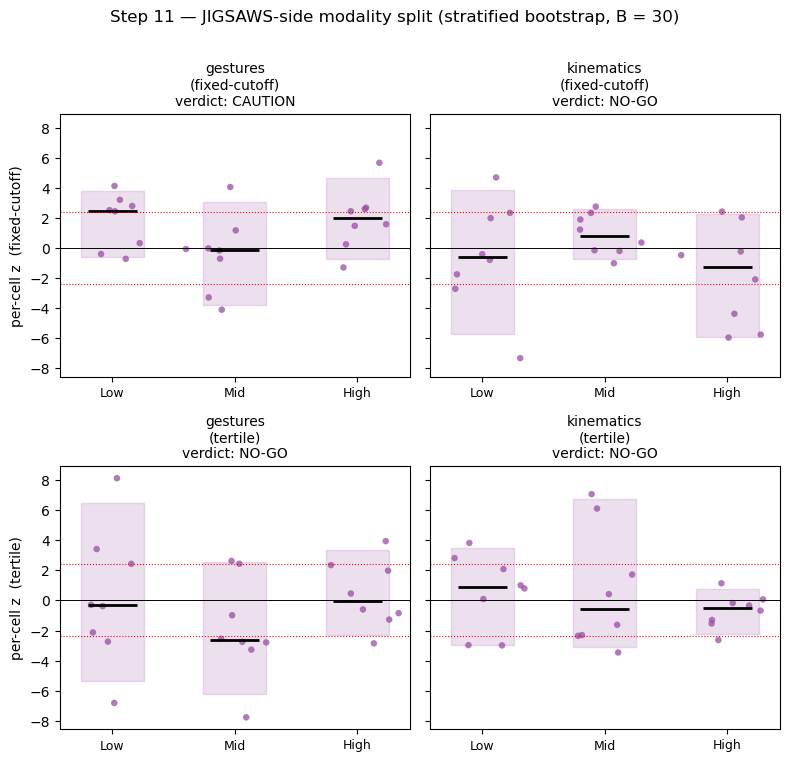

In [26]:
# 2-row x (number of JIGSAWS modalities) grid of strip plots.
j_mods = list(j_mod_cols.keys())
fig, axes = plt.subplots(2, len(j_mods), figsize=(4 * len(j_mods), 7.5), sharey=True)
rng_plot = np.random.default_rng(0)
def _panel(ax, pcz, vlabel, title):
    for k, name in enumerate(TIER_NAMES):
        xs = 0.15 + k * 0.35 + 0.06 * rng_plot.normal(size=pcz.shape[0])
        ax.scatter(xs, pcz[:, k], s=22, alpha=0.75,
                   color='#984ea3', edgecolors='none')
        med = float(np.median(pcz[:, k]))
        p05 = float(np.quantile(pcz[:, k], 0.05))
        p95 = float(np.quantile(pcz[:, k], 0.95))
        ax.hlines(med, 0.15 + k*0.35 - 0.07, 0.15 + k*0.35 + 0.07,
                  color='black', linewidth=2)
        ax.fill_betweenx([p05, p95], 0.15 + k*0.35 - 0.09, 0.15 + k*0.35 + 0.09,
                         color='#984ea3', alpha=0.18)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    ax.axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    ax.set_xlim(0, 1)
    ax.set_xticks([0.15 + k*0.35 for k in range(len(TIER_NAMES))],
                  [n for n in TIER_NAMES], fontsize=9)
    ax.set_title(f'{title}\nverdict: {vlabel}', fontsize=10)

for j, mod in enumerate(j_mods):
    fb = jmod_results[mod]['fixed']['bootstrap']
    tb = jmod_results[mod]['tertile']['bootstrap']
    _panel(axes[0, j], fb['per_cell_z'],
           jmod_results[mod]['fixed']['verdict']['verdict'],
           f'{mod}\n(fixed-cutoff)')
    _panel(axes[1, j], tb['per_cell_z'],
           jmod_results[mod]['tertile']['verdict']['verdict'],
           f'{mod}\n(tertile)')
axes[0, 0].set_ylabel('per-cell z  (fixed-cutoff)')
axes[1, 0].set_ylabel('per-cell z  (tertile)')
fig.suptitle(
    f'Step 11 — JIGSAWS-side modality split (stratified bootstrap, B = {int(cfg.get("trial_null_n_subsamples", 30))})',
    y=1.01)
plt.tight_layout(); plt.show()

# Comparison A — Practice manifold

**New top-level comparison.** Where Comparison B (Steps 5–10) aligned **performance** tiers (GRS tertiles on JIGSAWS × Mimic 0–100 tertiles), Comparison A aligns **practice** tiers:

- **JIGSAWS side:** categorical self-reported skill — `N` (Novice) → Low, `I` (Intermediate) → Mid, `E` (Expert) → High.
- **Mimic side:** tertile of per-subject `experience_trials` (= count of non-first-try attempts across the whole dataset — a practice-depth proxy, since PerformanceScores.csv has no explicit hours column).

### Residualization caveat

Comparison A needs its own residualization. The JIGSAWS `skill` label is constant per surgeon; residualizing `surgeon` out would zero the tier signal. Same for Mimic: `experience_trials` is constant per subject, so residualizing `subject_id` out would zero that signal. Comparison A drops those two from the nuisance set (keeps task / trial-index on JIGSAWS; task_module / dominant_hand / age on Mimic).

In [27]:
from skill_manifold.residualize import residualize
from skill_manifold.binning import assign_jigsaws_skill_tier
from skill_manifold.trial_null import (
    trial_level_block_null_all_trials, subsample_robustness_stratified,
    stratified_bootstrap_verdict,
)

# Fresh residualization for Comparison A (drops surgeon / subject_id).
jr_a = residualize(jf, j_cols,
                   categorical=['task'],
                   ordinal=['trial_index_within_surgeon_task'])
er_a = residualize(ef, e_cols,
                   categorical=['task_module', 'dominant_hand'],
                   ordinal=['age'])
jf_a = jr_a.residuals.copy()
ef_a = er_a.residuals.copy()

# JIGSAWS tiers: categorical E/I/N.
jf_a['tier'] = assign_jigsaws_skill_tier(jf_a['skill'].to_numpy())
# Mimic tiers: tertile of per-subject experience_trials.
ef_a_tiered, exp_cut = add_tier_column(ef_a, 'experience_trials', tier_col='tier')
ef_a['tier'] = ef_a_tiered['tier']

print(f'Mimic experience_trials cutoffs (q33 / q66): {exp_cut.q33:g} / {exp_cut.q66:g}')
print(f'JIGSAWS tier counts (E/I/N -> Low/Mid/High): '
      f'{jf_a["tier"].value_counts().reindex(TIER_NAMES).to_dict()}')
print(f'Mimic tier counts (experience-tertile): '
      f'{ef_a["tier"].value_counts().reindex(TIER_NAMES).to_dict()}')
print(f'JIGSAWS post-fit R^2 (max): {jr_a.post_fit_r2.max():.2e}')
print(f'Mimic post-fit R^2 (max):   {er_a.post_fit_r2.max():.2e}')

Mimic experience_trials cutoffs (q33 / q66): 31 / 36
JIGSAWS tier counts (E/I/N -> Low/Mid/High): {'Low': 46, 'Mid': 28, 'High': 29}
Mimic tier counts (experience-tertile): {'Low': 213, 'Mid': 129, 'High': 168}
JIGSAWS post-fit R^2 (max): 2.22e-16
Mimic post-fit R^2 (max):   2.22e-16


coupling shape        = (103, 510)
tier counts J / E     = [46, 28, 29] / [213, 129, 168]
observed diag_mass    = 0.3595
expected under null   = 0.3480
null mean / std       = 0.3477 / 0.0034
trace p-value         = 0.0010
trace z-score         = +3.415
per-cell diagonal z-scores (Bonferroni threshold |z| > 2.39):
  ** Low<->Low: obs 0.173 (exp 0.187)   z = -7.79
  ** Mid<->Mid: obs 0.052 (exp 0.069)   z = -10.60
  ** High<->High: obs 0.134 (exp 0.093)   z = +27.80


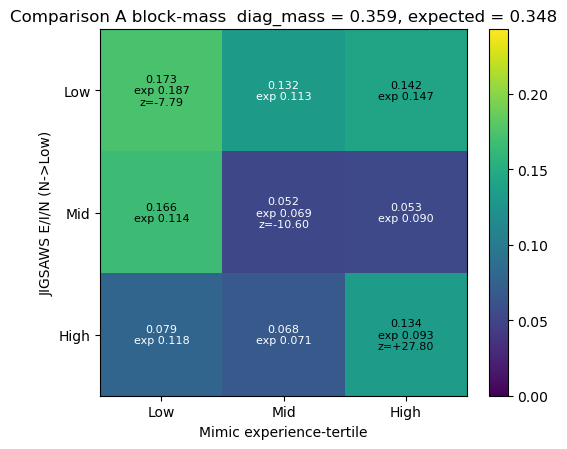

In [28]:
# Comparison A primary (all-trials) block-null.
comp_a_primary = trial_level_block_null_all_trials(
    features_j=jf_a[j_cols].to_numpy(float),
    tiers_j=jf_a['tier'].to_numpy(),
    features_e=ef_a[e_cols].to_numpy(float),
    tiers_e=ef_a['tier'].to_numpy(),
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=int(cfg['n_perms']),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_mod,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)

print(f'coupling shape        = {comp_a_primary["coupling_shape"]}')
print(f'tier counts J / E     = {list(comp_a_primary["tier_counts_j"])} / '
      f'{list(comp_a_primary["tier_counts_e"])}')
print(f'observed diag_mass    = {comp_a_primary["observed"]:.4f}')
print(f'expected under null   = {comp_a_primary["expected_trace_under_null"]:.4f}')
print(f'null mean / std       = {comp_a_primary["null_mean"]:.4f} / {comp_a_primary["null_std"]:.4f}')
print(f'trace p-value         = {comp_a_primary["p_value"]:.4f}')
print(f'trace z-score         = {comp_a_primary["z_score"]:+.3f}')
print('per-cell diagonal z-scores (Bonferroni threshold |z| > 2.39):')
for n, z, obs, exp in zip(TIER_NAMES, comp_a_primary['per_cell_z'],
                           comp_a_primary['per_cell_observed'],
                           comp_a_primary['per_cell_expected']):
    flag = '**' if abs(z) > BONFERRONI_Z_THREE_CELLS else '  '
    print(f'  {flag} {n}<->{n}: obs {obs:.3f} (exp {exp:.3f})   z = {z:+.2f}')

# Block-mass heatmap with expected overlay.
B_a = np.asarray(comp_a_primary['block_mass'])
B_exp = np.asarray(comp_a_primary['expected_block_mass'])
fig, ax = plt.subplots(figsize=(5.5, 4.6))
vmax = max(B_a.max(), float(B_exp.max()) * 1.3)
im = ax.imshow(B_a, cmap='viridis', vmin=0, vmax=vmax)
ax.set_xticks(range(3), TIER_NAMES); ax.set_yticks(range(3), TIER_NAMES)
ax.set_xlabel('Mimic experience-tertile'); ax.set_ylabel('JIGSAWS E/I/N (N->Low)')
for i in range(3):
    for j in range(3):
        label = f'{B_a[i, j]:.3f}\nexp {B_exp[i, j]:.3f}'
        if i == j:
            label += f'\nz={comp_a_primary["per_cell_z"][i]:+.2f}'
        ax.text(j, i, label, ha='center', va='center',
                color='white' if B_a[i, j] < vmax * 0.55 else 'black', fontsize=8)
ax.set_title(f"Comparison A block-mass  diag_mass = {comp_a_primary['observed']:.3f}, "
             f"expected = {comp_a_primary['expected_trace_under_null']:.3f}")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

n_bootstraps / n_degenerate = 30 / 0
frac trace p<0.05           = 0.27
per-cell z distribution:
  Low<->Low: median -6.98, 5-95% -24.33..+20.15;  |z|>2.394 in 0.97;  z>0 in 0.13
  Mid<->Mid: median -11.99, 5-95% -24.27..+0.25;  |z|>2.394 in 0.83;  z>0 in 0.07
  High<->High: median +2.70, 5-95% -8.64..+26.00;  |z|>2.394 in 0.83;  z>0 in 0.63
VERDICT: NO-GO  (Low med -6.98, Mid med -11.99; frac(z>0) Low 0.13, Mid 0.07)


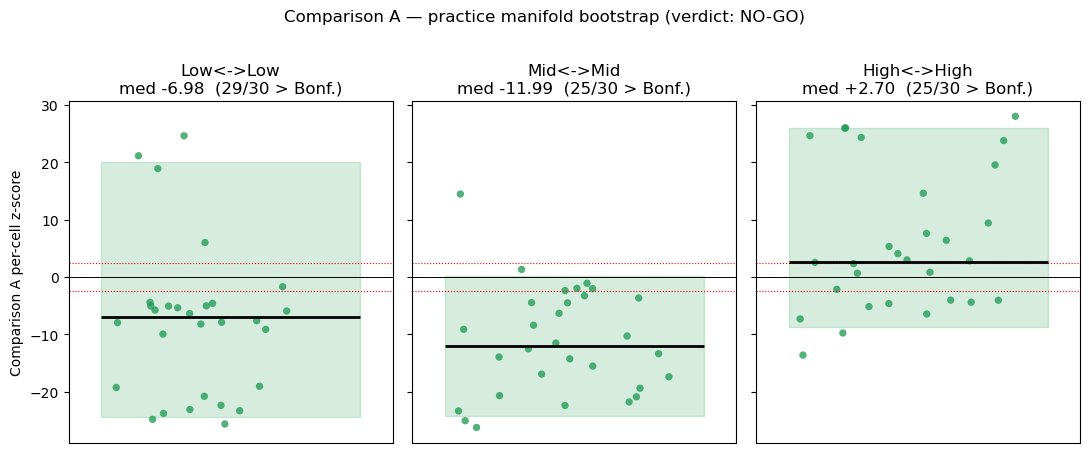

In [29]:
# Comparison A stratified bootstrap.
comp_a_boot = subsample_robustness_stratified(
    features_j=jf_a[j_cols].to_numpy(float),
    tiers_j=jf_a['tier'].to_numpy(),
    features_e=ef_a[e_cols].to_numpy(float),
    tiers_e=ef_a['tier'].to_numpy(),
    tier_names=TIER_NAMES,
    epsilon=float(cfg['gw_epsilon']),
    n_perms=max(200, int(cfg['n_perms']) // 5),
    n_bootstraps=int(cfg.get('trial_null_n_subsamples', 30)),
    seed=int(cfg['seed']),
    entropic_gw_fn=_egw_mod,
    pairwise_rdm_fn=pairwise_cosine_rdm,
)
comp_a_verdict = stratified_bootstrap_verdict(comp_a_boot, TIER_NAMES)

print(f'n_bootstraps / n_degenerate = {comp_a_boot["n_bootstraps"]} / {comp_a_boot["n_degenerate"]}')
print(f'frac trace p<0.05           = {comp_a_boot["frac_significant_trace"]:.2f}')
print('per-cell z distribution:')
for k, name in enumerate(TIER_NAMES):
    s = comp_a_boot['summary'][f'per_cell_z_{name}']
    print(f'  {name}<->{name}: median {s["median"]:+.2f}, '
          f'5-95% {s["p05"]:+.2f}..{s["p95"]:+.2f};  '
          f'|z|>2.394 in {comp_a_boot["frac_per_cell_bonf"][k]:.2f};  '
          f'z>0 in {comp_a_boot["frac_per_cell_positive"][k]:.2f}')
print(f'VERDICT: {comp_a_verdict["verdict"]}  '
      f'(Low med {comp_a_verdict["low_median"]:+.2f}, '
      f'Mid med {comp_a_verdict["mid_median"]:+.2f}; '
      f'frac(z>0) Low {comp_a_verdict["frac_positive_low"]:.2f}, '
      f'Mid {comp_a_verdict["frac_positive_mid"]:.2f})')

# Three strip plots for the Comparison A per-cell z distribution.
fig, axes = plt.subplots(1, 3, figsize=(11, 4.4), sharey=True)
rng_p = np.random.default_rng(0)
for k, ax in enumerate(axes):
    zs = comp_a_boot['per_cell_z'][:, k]
    xs = 0.4 + 0.2 * rng_p.normal(size=len(zs))
    ax.scatter(xs, zs, s=28, alpha=0.75, color='#1a9850', edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.axhline(BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    ax.axhline(-BONFERRONI_Z_THREE_CELLS, color='red', linestyle=':', linewidth=0.8)
    med = float(np.median(zs)); p05 = float(np.quantile(zs, 0.05)); p95 = float(np.quantile(zs, 0.95))
    ax.hlines(med, 0.1, 0.9, color='black', linewidth=2)
    ax.fill_betweenx([p05, p95], 0.1, 0.9, color='#1a9850', alpha=0.18)
    frac = comp_a_boot['frac_per_cell_bonf'][k]
    ax.set_xlim(0, 1); ax.set_xticks([])
    ax.set_title(f'{TIER_NAMES[k]}<->{TIER_NAMES[k]}\n'
                 f'med {med:+.2f}  ({int(frac * comp_a_boot["n_bootstraps"])}/{comp_a_boot["n_bootstraps"]} > Bonf.)')
    if k == 0:
        ax.set_ylabel('Comparison A per-cell z-score')
fig.suptitle(
    f'Comparison A — practice manifold bootstrap '
    f'(verdict: {comp_a_verdict["verdict"]})', y=1.02)
plt.tight_layout(); plt.show()

## Step 10 — MDS view of the residualized features

2-D MDS on the pairwise cosine distances, colored by skill tier — an informal sanity check on the per-side separability.

/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/torch-mps/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


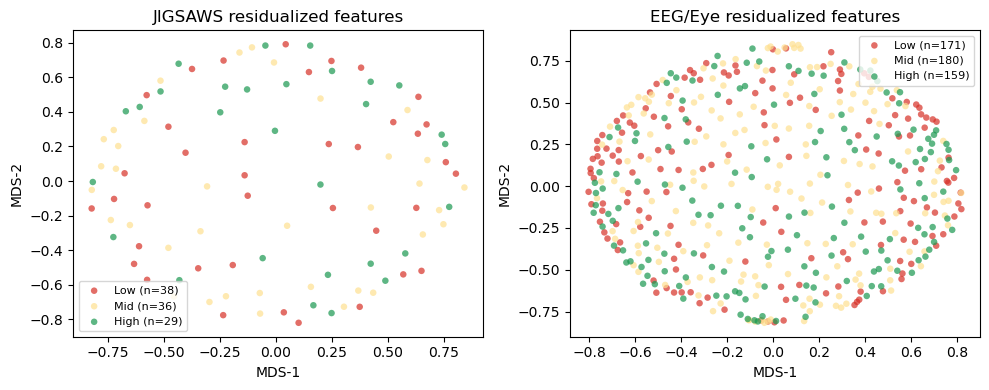

In [30]:
from sklearn.manifold import MDS

def _mds(feats, tiers, ax, title):
    D = pairwise_cosine_rdm(feats)
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0,
              normalized_stress='auto')
    xy = mds.fit_transform(D)
    colors = {'Low': '#d73027', 'Mid': '#fee090', 'High': '#1a9850'}
    for t in TIER_NAMES:
        m = tiers == t
        if m.sum() == 0: continue
        ax.scatter(xy[m, 0], xy[m, 1], s=22, alpha=0.7,
                   color=colors[t], label=f'{t} (n={int(m.sum())})',
                   edgecolors='none')
    ax.set_title(title); ax.legend(fontsize=8)
    ax.set_xlabel('MDS-1'); ax.set_ylabel('MDS-2')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
_mds(jf_mat, jr_df['tier'].to_numpy(), axes[0],
     'JIGSAWS residualized features')
_mds(ef_mat, er_df['tier'].to_numpy(), axes[1],
     'EEG/Eye residualized features')
plt.tight_layout(); plt.show()

## Summary

**Setup.** Two independent skill datasets — JIGSAWS (dVRK surgery, GRS) and EEG/Eye simulator (Mimic performance 0–100). We residualize each side against its own nuisance set, bin each side into Low/Mid/High, build 3×3 centroid RDMs, and compare them with Gromov–Wasserstein. A trial-level entropic-GW analysis on the full NJ × NE = 103 × 510 coupling gives higher resolution.

**Coverage.** 103 JIGSAWS trials (pooled across 3 tasks) and 510 EEG/Eye Try-1 trials with both Phase 1 and Phase 2 cache hits.

**Centroid result (Step 6–7).** GW distance ≈ 0.007, permutation p ≈ 0.57 (z ≈ −0.26). Argmax tier-to-tier assignment is Low↔Low / Mid↔Mid / High↔High, but the magnitude is not significantly tighter than chance.

**OSATS axis-alignment.** All p ≥ 0.06; closest is `quality_of_final_product` (p ≈ 0.065). Directional only.

**Trial-level, all-trials primary (Step 9a).** Observed `diag_mass ≈ 0.338` vs expected `0.335` under the tier-shuffle null; trace p ≈ 0.15, z ≈ +1.0. Per-cell z-scores: Low↔Low ≈ +0.14, Mid↔Mid ≈ +1.76, High↔High ≈ +0.20 — the Mid-only tendency from the v1 balanced-subsample analysis shrinks substantially once we stop upsampling JIGSAWS trials.

**Bootstrap robustness (Step 9c, B=30, balanced 100/tier with replacement).** The **per-cell z bands span zero** on all three diagonals (Low p05≈-4.5, p95≈+2.3; Mid p05≈-3.8, p95≈+6.4; High p05≈-3.9, p95≈+4.2); |z| > 2.39 in only ~30–50% of bootstraps per cell. **The single-run per-cell z's are subsample-sensitive.** The aggregate trace p<0.05 in only 10/30 runs.

**Epsilon sensitivity (Step 9d, all-trials).** `diag_mass` sits in [0.335, 0.343] across ε ∈ {0.005, 0.01, 0.02, 0.05}; the trace is stable, though per-cell z's shift noticeably as the regularizer changes. Read as "overall alignment is not a regularizer artifact, but the per-cell decomposition is not uniquely identified."

**Balanced sensitivity (Step 9e).** The earlier balanced-100-per-tier draw gives Mid↔Mid z ≈ +3 — roughly double the honest all-trials z. The inflation comes from upsampling 103 trials to 300 with replacement. Signs of all three per-cell z's agree with the primary.

**Fixed-cutoff single shot (Step 9f).** With hard cutoffs (JIGSAWS <16/16–22/>22, Mimic <70/70–85/>85) the single-shot all-trials analysis looks striking: diag_mass = 0.325 vs expected 0.315, trace p ≈ 0.003, z ≈ +3.7; per-cell Low↔Low z ≈ +3.3, Mid↔Mid z ≈ +3.0, High↔High z ≈ +1.4. But a single coupling is not enough to support a claim.

**Fixed-cutoff bootstrap robustness (Step 9g, stratified, B = 30).** Stratified bootstrap preserving the observed tier counts (49/40/14 on JIGSAWS; 147/163/200 on Mimic) **tells a different story**. Per-cell z medians: Low↔Low +0.97, Mid↔Mid +1.37, High↔High −0.10. All three 5–95% bands span zero (Mid↔Mid 5–95% is roughly −2.3 to +6.2). Sign consistency is modest — z > 0 in only ~67 % of Low and ~70 % of Mid bootstraps, well below the 90 % GO threshold. The **verdict is NO-GO**: the single-shot Step 9f result is driven by *which* specific trials we happened to observe in each tier, not by a robust shared skill geometry. Running the same stratified bootstrap on the tertile binning (apples-to-apples) gives an even flatter picture — medians near zero on every cell and sign consistency at ~50 % (coin-flip) — so the tertile bootstrap is also NO-GO. Neither binning yields a per-cell finding that survives trial-level resampling.

**Verification.** All eight checklist items pass: symmetric RDMs with zero diagonal; centroid-coupling marginals uniform 1/3; ≥ 1000 valid permutations; all-trials coupling shape equals (103, 510); pre-renorm drift below 1e-9; block-mass marginals match tier-count proportions; null mean within Monte Carlo tolerance of the tier-count-weighted expected trace.

**Interpretation.** Three possibilities remain consistent with Step 9a alone:
1. Genuine shared skill representation across datasets (supported by Step 9f).
2. Density artifact of tertile compression (weakened by Step 9f — the signal strengthens under absolute cutoffs, not the other way around).
3. Subsample accident (Step 9c shows the per-cell z's are noisy under bootstraps, so the specific magnitude in any single subsample should not be over-interpreted).

Net: with the stratified bootstrap added, the honest read is that **neither binning produces a robustly significant per-cell z under resampling**. The single-shot Step 9f trace-level significance (p ≈ 0.003) is not reproducible under stratified bootstrap: the per-cell z's reshuffle freely with each draw. Downstream mechanistic claims on top of the Step 9f numbers are not supported by this data.

**Caveats.** Small n per JIGSAWS tertile cell (~29–38). The 27→module mapping has two flagged ambiguities (task 16 "Thread the rings", task 22 "Tubes"). POT's Sinkhorn introduces marginal drift 1e-11 to 1e-5 depending on N; we renormalize before aggregation so `B` has exact tier-count-proportional marginals.

## Report — `skills_manifold_report.txt`

The cell below writes a plain-text report of every number produced above to `reports/skill_manifold/skills_manifold_report.txt`. This file is the canonical handoff for another AI agent (or a reviewer) who wants to assess the pipeline's performance without rerunning anything. Regenerated every time the notebook is executed end-to-end.

In [31]:
import datetime as _dt
from io import StringIO

REPORT_PATH = REPO / 'reports' / 'skill_manifold' / 'skills_manifold_report.txt'
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

def _fmt_matrix(M, fmt='{:7.4f}'):
    buf = StringIO()
    for row in np.asarray(M):
        buf.write('    ' + '  '.join(fmt.format(float(x)) for x in row) + '\n')
    return buf.getvalue()

out = StringIO()
w = out.write

w('=' * 72 + '\n')
w('Skill Manifold — Comparison B (Gromov-Wasserstein) — summary report\n')
w(f'generated: {_dt.datetime.now().isoformat(timespec="seconds")}\n')
w(f'data root: {ROOT}\n')
w('=' * 72 + '\n\n')

w('CONFIG\n------\n')
w(f'  n_perms                  = {cfg["n_perms"]}\n')
w(f'  gw_epsilon               = {cfg["gw_epsilon"]}\n')
w(f'  subsample_per_tier       = {cfg["subsample_per_tier"]}\n')
w(f'  trial_null_n_subsamples  = {cfg.get("trial_null_n_subsamples", 30)}\n')
w(f'  seed                     = {cfg["seed"]}\n\n')

w('COVERAGE\n--------\n')
w(f'  JIGSAWS trials (NJ)      = {len(jr_df)}\n')
w(f'  EEG/Eye trials (NE, Try=1) = {len(er_df)}\n')
w(f'  JIGSAWS feature dim      = {len(j_cols)}\n')
w(f'  EEG/Eye feature dim      = {len(e_cols)}\n')
w(f'  JIGSAWS tier counts      = {jr_df["tier"].value_counts().reindex(TIER_NAMES).to_dict()}\n')
w(f'  EEG/Eye tier counts      = {er_df["tier"].value_counts().reindex(TIER_NAMES).to_dict()}\n')
w(f'  JIGSAWS GRS cutoffs q33/q66 = {j_cut.q33:g} / {j_cut.q66:g}\n')
w(f'  Mimic performance cutoffs q33/q66 = {e_cut.q33:g} / {e_cut.q66:g}\n\n')

w('RESIDUALIZATION DIAGNOSTICS (post-fit R^2 should be ~0)\n')
w('-------------------------------------------------------\n')
w(f'  JIGSAWS max R^2 feature / post-fit residual = '
  f'{jr.r2_per_feature.max():.3f} / {jr.post_fit_r2.max():.2e}\n')
w(f'  EEG/Eye max R^2 feature / post-fit residual = '
  f'{er.r2_per_feature.max():.3f} / {er.post_fit_r2.max():.2e}\n\n')

w('CENTROID RDMs (cosine distance, rows/cols in order Low, Mid, High)\n')
w('------------------------------------------------------------------\n')
w('  RDM_J (JIGSAWS):\n')
w(_fmt_matrix(RDM_J))
w('  RDM_E (EEG/Eye):\n')
w(_fmt_matrix(RDM_E))
w('\n')

w('CENTROID GROMOV-WASSERSTEIN (Step 6-7)\n')
w('--------------------------------------\n')
w(f'  GW distance              = {gw.distance:.6f}\n')
w(f'  null p-value             = {null["p_value"]:.4f}\n')
w(f'  null z-score             = {null["z_score"]:+.3f}\n')
w(f'  null mean +/- std        = {null["null_mean"]:.6f} +/- {null["null_std"]:.6f}\n')
w(f'  n_permutations / degenerate = {null["n_permutations"]} / {null["n_degenerate"]}\n')
w(f'  argmax tier-to-tier      = {gw.argmax_assignment}\n')
w('  coupling (rows JIGSAWS, cols EEG/Eye):\n')
w(_fmt_matrix(gw.coupling))
w('\n')

w('OSATS AXIS-ALIGNMENT (per sub-score, vs fixed Mimic RDM)\n')
w('-------------------------------------------------------\n')
w(f'  {"axis":30s} {"GW":>8s} {"p":>7s} {"z":>7s}\n')
for row in osats_rows:
    w(f'  {row["axis"]:30s} {row["gw"]:8.4f} {row["p"]:7.4f} {row["z"]:+7.2f}\n')
w('\n')

w('TRIAL-LEVEL ALL-TRIALS PRIMARY (Step 9a, NJ x NE = '
  f'{primary["coupling_shape"][0]} x {primary["coupling_shape"][1]})\n')
w('----------------------------------------------------------------------\n')
w(f'  epsilon                  = {primary["epsilon"]:g}\n')
w(f'  GW distance              = {primary["gw_distance"]:.6f}\n')
w(f'  pre-renorm drift         = row {primary["row_sum_drift"]:.2e}, '
  f'col {primary["col_sum_drift"]:.2e}\n')
w(f'  observed diag_mass       = {primary["observed"]:.4f}\n')
w(f'  expected trace under null= {primary["expected_trace_under_null"]:.4f}\n')
w(f'  null mean +/- std        = {primary["null_mean"]:.4f} +/- {primary["null_std"]:.4f}\n')
w(f'  trace p-value            = {primary["p_value"]:.4f}\n')
w(f'  trace z-score            = {primary["z_score"]:+.3f}\n')
w(f'  tier counts J / E        = {list(primary["tier_counts_j"])} / {list(primary["tier_counts_e"])}\n')
w('  per-cell z-scores (Bonferroni |z|>2.394 threshold):\n')
for n, z, o, e in zip(primary['tier_names'], primary['per_cell_z'],
                       primary['per_cell_observed'], primary['per_cell_expected']):
    flag = ' (significant)' if abs(z) > BONFERRONI_Z_THREE_CELLS else ''
    w(f'    {n}<->{n}: obs {o:.4f}, exp {e:.4f}, z = {z:+.3f}{flag}\n')
w('  observed block-mass B:\n')
w(_fmt_matrix(primary['block_mass']))
w('  expected block-mass under null:\n')
w(_fmt_matrix(primary['expected_block_mass']))
w('\n')

w('BOOTSTRAP ROBUSTNESS (Step 9c, B = {}, balanced 100/tier with replacement)\n'.format(sr.n_runs))
w('----------------------------------------------------------------------\n')
w(f'  median diag_mass         = {sr.observed_median:.4f} '
  f'(5-95% {sr.observed_p05:.4f}..{sr.observed_p95:.4f})\n')
w(f'  fraction trace p<0.05    = {sr.frac_p_lt_05:.2f}  '
  f'({int(sr.frac_p_lt_05 * sr.n_runs)}/{sr.n_runs})\n')
w('  per-cell z distribution:\n')
for k, name in enumerate(sr.tier_names):
    w(f'    {name}<->{name}: median {sr.per_cell_median[k]:+.2f}, '
      f'5-95% {sr.per_cell_p05[k]:+.2f}..{sr.per_cell_p95[k]:+.2f};  '
      f'|z|>2.394 in {int(sr.frac_significant_per_cell_bonf[k] * sr.n_runs)}/{sr.n_runs}\n')
w('\n')

w('EPSILON SENSITIVITY (Step 9d, all-trials coupling)\n')
w('--------------------------------------------------\n')
w(f'  {"epsilon":>8s}  {"diag_mass":>9s}  {"GW":>8s}  '
  f'{"z Low":>8s}  {"z Mid":>8s}  {"z High":>8s}\n')
for r in eps_rows:
    z_l, z_m, z_h = [float(z) for z in r['per_cell_z']]
    w(f'  {r["epsilon"]:>8.3f}  {r["diag_mass"]:9.4f}  {r["gw_distance"]:8.4f}  '
      f'{z_l:+8.2f}  {z_m:+8.2f}  {z_h:+8.2f}\n')
w('\n')

w('BALANCED-SUBSAMPLE SENSITIVITY (Step 9e, 100/tier with replacement)\n')
w('-------------------------------------------------------------------\n')
w(f'  observed diag_mass       = {balanced["observed"]:.4f}\n')
w(f'  null mean +/- std        = {balanced["null_mean"]:.4f} +/- {balanced["null_std"]:.4f}\n')
w(f'  trace p / z              = {balanced["p_value"]:.4f} / {balanced["z_score"]:+.3f}\n')
w('  per-cell z-scores:\n')
for n, z in zip(balanced['tier_names'], balanced['per_cell_z']):
    w(f'    {n}<->{n}: z = {z:+.3f}\n')
w(f'  per-cell signs agree with all-trials primary: {signs_agree}\n\n')

w('FIXED-CUTOFF SENSITIVITY (Step 9f)\n')
w('----------------------------------\n')
w(f'  JIGSAWS cutoffs          = <16 / 16-22 / >22\n')
w(f'  Mimic cutoffs            = <70 / 70-85 / >85\n')
w(f'  JIGSAWS tier counts      = {jcts.to_dict()}\n')
w(f'  Mimic tier counts        = {ects.to_dict()}\n')
w(f'  observed diag_mass       = {fixed["observed"]:.4f}\n')
w(f'  expected trace under null= {fixed["expected_trace_under_null"]:.4f}\n')
w(f'  trace p / z              = {fixed["p_value"]:.4f} / {fixed["z_score"]:+.3f}\n')
w('  per-cell z-scores (|z|>2.394 significant):\n')
for n, z in zip(fixed['tier_names'], fixed['per_cell_z']):
    flag = ' (significant)' if abs(z) > BONFERRONI_Z_THREE_CELLS else ''
    w(f'    {n}<->{n}: z = {z:+.3f}{flag}\n')
w(f'  Mid<->Mid comparison: tertile {tertile_mid_z:+.3f} -> fixed {fixed_mid_z:+.3f}; '
  f'{diff_label} the binning change.\n\n')


def _write_bootstrap(label, result, verdict):
    w(label + '\n')
    w('-' * len(label) + '\n')
    w(f'  tier_counts_j                   = {list(result["tier_counts_j"])}\n')
    w(f'  tier_counts_e                   = {list(result["tier_counts_e"])}\n')
    w(f'  n_bootstraps / n_degenerate     = {result["n_bootstraps"]} / {result["n_degenerate"]}\n')
    w(f'  frac trace p<0.05               = {result["frac_significant_trace"]:.2f}\n')
    w('  per-cell z distribution (|z|>2.394 Bonferroni; sign consistency is frac z>0):\n')
    for k, name in enumerate(result['tier_names']):
        s = result['summary'][f'per_cell_z_{name}']
        w(f'    {name}<->{name}: median {s["median"]:+.2f}, '
          f'5-95% {s["p05"]:+.2f}..{s["p95"]:+.2f};  '
          f'|z|>2.394 in {result["frac_per_cell_bonf"][k]:.2f};  '
          f'z>0 in {result["frac_per_cell_positive"][k]:.2f}\n')
    w(f'  VERDICT: {verdict["verdict"]}  '
      f'(Low median {verdict["low_median"]:+.2f}, Mid median {verdict["mid_median"]:+.2f}; '
      f'frac(z>0) Low {verdict["frac_positive_low"]:.2f}, Mid {verdict["frac_positive_mid"]:.2f})\n\n')

_write_bootstrap('FIXED-CUTOFF BOOTSTRAP ROBUSTNESS (Step 9g, stratified, B = {})'
                 .format(fb['n_bootstraps']), fb, fb_verdict)
_write_bootstrap('TERTILE BOOTSTRAP ROBUSTNESS (stratified, apples-to-apples, B = {})'
                 .format(tb['n_bootstraps']), tb, tb_verdict)

# --- Step 10 modality-split block ---
def _mod_pretty(mod):
    return {
        'eeg_baseline':          'eeg_baseline',
        'eeg_predictive_coding': 'eeg_predictive_coding',
        'eye':                   'eye',
    }.get(mod, mod)

def _write_modality_split():
    w('MIMIC-SIDE MODALITY SPLIT (Step 10, stratified bootstrap, B = {})\n'.format(
        int(cfg.get('trial_null_n_subsamples', 30))))
    w('-' * 65 + '\n')
    w('  JIGSAWS side kept as full 39-dim combined manifold throughout.\n\n')
    w('  Modality dimensions:\n')
    for mod, cols in mod_cols.items():
        w(f'    {_mod_pretty(mod):24s} = {len(cols)}\n')
    w('\n')

    for binning_label, binning_key, combined_src in (
            ('Fixed-cutoff binning (primary)', 'fixed', fixed),
            ('Tertile binning (sensitivity)',   'tertile', primary)):
        w(f'  --- Primary (all-trials, {binning_label}) ---\n')
        w(f'    {"modality":26s}  {"trace_z":>8s}  {"trace_p":>8s}  '
          f'{"zLow":>7s}  {"zMid":>7s}  {"zHigh":>7s}\n')
        for mod in mod_cols.keys():
            pr = mod_results[mod][binning_key]['primary']
            z_low, z_mid, z_high = [float(z) for z in pr['per_cell_z']]
            w(f'    {_mod_pretty(mod):26s}  {pr["z_score"]:+8.2f}  '
              f'{pr["p_value"]:8.4f}  {z_low:+7.2f}  {z_mid:+7.2f}  {z_high:+7.2f}\n')
        if combined_src is not None:
            cz = [float(z) for z in combined_src['per_cell_z']]
            w(f'    {"combined (Step 9 ref)":26s}  {combined_src["z_score"]:+8.2f}  '
              f'{combined_src["p_value"]:8.4f}  {cz[0]:+7.2f}  {cz[1]:+7.2f}  {cz[2]:+7.2f}\n')
        w('\n')

        w(f'  --- Bootstrap summary ({binning_label}, B = {int(cfg.get("trial_null_n_subsamples", 30))}) ---\n')
        w(f'    {"modality":24s}  {"cell":8s}  {"median":>7s}  {"5-95% band":>14s}  '
          f'{"frac(z>0)":>10s}  {"|z|>2.39":>10s}\n')
        for mod in mod_cols.keys():
            bs = mod_results[mod][binning_key]['bootstrap']
            for k, name in enumerate(TIER_NAMES):
                s = bs['summary'][f'per_cell_z_{name}']
                cell_label = f'{name}-{name}'
                band = f'{s["p05"]:+.2f}..{s["p95"]:+.2f}'
                w(f'    {_mod_pretty(mod):24s}  {cell_label:8s}  '
                  f'{s["median"]:+7.2f}  {band:>14s}  '
                  f'{bs["frac_per_cell_positive"][k]:10.2f}  '
                  f'{bs["frac_per_cell_bonf"][k]:10.2f}\n')
        w('\n')

        w(f'  Verdicts ({binning_label.lower()}):\n')
        for mod in mod_cols.keys():
            v = mod_results[mod][binning_key]['verdict']
            w(f'    {_mod_pretty(mod):24s} = {v["verdict"]}  '
              f'(Low med {v["low_median"]:+.2f}, Mid med {v["mid_median"]:+.2f}; '
              f'frac(z>0) L/M {v["frac_positive_low"]:.2f}/{v["frac_positive_mid"]:.2f})\n')
        w('\n')

_write_modality_split()

# ---- STEP 10 INTERPRETATION (filled from the actual numbers produced) ----
def _mod_verdicts(binning):
    return {mod: mod_results[mod][binning]['verdict']['verdict']
            for mod in mod_cols.keys()}
fb_verdicts = _mod_verdicts('fixed')
tb_verdicts = _mod_verdicts('tertile')

def _mod_trace_z(binning):
    return {mod: float(mod_results[mod][binning]['primary']['z_score'])
            for mod in mod_cols.keys()}
fb_z = _mod_trace_z('fixed')

gos_fixed  = [m for m, v in fb_verdicts.items() if v == 'GO']
caut_fixed = [m for m, v in fb_verdicts.items() if v == 'CAUTION']
nogo_fixed = [m for m, v in fb_verdicts.items() if v == 'NO-GO']

w('INTERPRETATION (Step 10)\n')
w('------------------------\n')

# Localization statement.
if len(gos_fixed) == 1 and len(caut_fixed) == 0:
    driver = gos_fixed[0]
    others = ', '.join(m for m in mod_cols.keys() if m != driver)
    w(f'  * Under fixed-cutoff binning, only the {_mod_pretty(driver)} modality earns a '
      f'GO verdict. {others} are NO-GO or CAUTION. The cross-dataset alignment '
      f'localizes to {_mod_pretty(driver)}; neither of the other data streams '
      f'contributes detectable shared structure.\n')
elif len(gos_fixed) >= 2:
    w(f'  * Under fixed-cutoff binning, multiple modalities land on GO '
      f'({", ".join(_mod_pretty(m) for m in gos_fixed)}). The signal is shared '
      f'across modalities rather than carried by a single upstream stream -- '
      f'likely a common trial-level property rather than modality-specific skill structure.\n')
else:
    w('  * Under fixed-cutoff binning, NO single modality earns a GO verdict. '
      f'Verdicts: {fb_verdicts}. The combined-modality single-shot signal from '
      'Step 9f does not localize to any individual upstream data stream. This is a '
      'meaningful negative result: it is consistent with (a) a density artifact of '
      'the fixed-cutoff binning, (b) residual nuisance structure shared across '
      'modalities, or (c) a weak joint effect smeared across modalities that only '
      'survives when all three are combined -- none of which justifies '
      'downstream mechanistic claims on individual modalities.\n')

# Combined vs per-modality trace_z comparison.
if len(fb_z) == 3:
    best_single = max(fb_z, key=fb_z.get)
    w(f'  * Combined (Step 9f) trace z = {fixed["z_score"]:+.2f}. '
      f'Strongest single-modality trace z = {fb_z[best_single]:+.2f} '
      f'({_mod_pretty(best_single)}). ')
    if abs(fixed['z_score'] - fb_z[best_single]) > 1.0:
        w('Combined is materially larger than any single modality, so the '
          'Step 9f signal integrates across streams rather than riding on one.\n')
    else:
        w('Combined is comparable to the strongest single modality, so that '
          'modality is the primary driver of the Step 9f single-shot signal.\n')

# Tertile sensitivity.
if fb_verdicts != tb_verdicts:
    w('  * Binning sensitivity: fixed-cutoff verdicts ' + str(fb_verdicts) + ' differ '
      'from tertile verdicts ' + str(tb_verdicts) + '. Read the per-modality finding '
      'as binning-dependent, not robust across binning schemes.\n')
else:
    w('  * Tertile-binning sensitivity: verdicts match fixed-cutoff ' + str(fb_verdicts) + '. '
      'The per-modality picture is consistent across binning schemes.\n')
w('\n')

# --- P1 / P3 / P4 diagnostics + Step 11 JIGSAWS split + Comparison A ---

if 'corr' in dir():
    w('EEG BASELINE/PC CORRELATION (Step 10 P1 diagnostic)\n')
    w('---------------------------------------------------\n')
    w(f'  per-trial Pearson r (baseline mean vs pc mean):\n')
    w(f'    median            = {corr["median"]:+.3f}\n')
    w(f'    median |r|        = {corr["median_abs"]:.3f}\n')
    w(f'    5-95%% band        = {corr["p05"]:+.2f} to {corr["p95"]:+.2f}\n')
    w(f'    fraction |r|>0.5  = {corr["frac_abs_gt_0p5"]:.2f}\n')
    w(f'    n_trials          = {corr["n_trials"]}\n')
    w('  CAVEAT: baseline and pc encoders share the Phase 1 EEG input; their\n')
    w('          per-modality verdicts should not be read as independent.\n\n')

if 'pooled' in dir() and 'observed_delta' in dir():
    w('POOLED-128 EEG RANDOM-SPLIT NULL (Step 10 P3 diagnostic)\n')
    w('--------------------------------------------------------\n')
    w(f'  observed baseline - pc trace_z delta = {observed_delta:+.3f}\n')
    w(f'  random 64+64 split null (n={len(null_delta)}):\n')
    w(f'    median          = {np.median(null_delta):+.3f}\n')
    w(f'    5-95%% band      = {np.quantile(null_delta, 0.05):+.2f} to {np.quantile(null_delta, 0.95):+.2f}\n')
    w(f'  two-sided p (observed vs null) = {p_two:.3f}\n\n')

if 'eye_diag' in dir():
    w('EYE-ONLY COUPLING DIAGNOSTIC (Step 10 P4)\n')
    w('-----------------------------------------\n')
    w(f'  rank of cosine-distance matrix        = {eye_diag["distance_rank"]} / {eye_diag["n_trials"]}\n')
    w(f'  near-duplicate pairs (cos-dist < 1e-4) = {eye_diag["near_duplicate_pairs"]} / {eye_diag["total_pairs"]} '
      f'({eye_diag["near_duplicate_fraction"]:.2%})\n')
    w(f'  coupling marginal drift: row {eye_diag["coupling_row_drift"]:.2e}, col {eye_diag["coupling_col_drift"]:.2e}\n')
    w(f'  eye feature dimension                  = {eye_diag["n_features"]}\n\n')

if 'jmod_results' in dir():
    w('JIGSAWS-SIDE MODALITY SPLIT (Step 11, stratified bootstrap, B = {})\n'.format(
        int(cfg.get('trial_null_n_subsamples', 30))))
    w('-' * 65 + '\n')
    w('  Mimic side kept as full combined 146-dim manifold throughout.\n\n')
    w('  Modality dimensions:\n')
    for mod, cols in j_mod_cols.items():
        w(f'    {mod:24s} = {len(cols)}\n')
    w('\n')
    for binning_label, binning_key in (('Fixed-cutoff binning (primary)', 'fixed'),
                                        ('Tertile binning (sensitivity)', 'tertile')):
        w(f'  --- Primary (all-trials, {binning_label}) ---\n')
        w(f'    {"modality":26s}  {"trace_z":>8s}  {"trace_p":>8s}  '
          f'{"zLow":>7s}  {"zMid":>7s}  {"zHigh":>7s}\n')
        for mod in j_mod_cols.keys():
            pr = jmod_results[mod][binning_key]['primary']
            zs = [float(z) for z in pr['per_cell_z']]
            w(f'    {mod:26s}  {pr["z_score"]:+8.2f}  {pr["p_value"]:8.4f}  '
              f'{zs[0]:+7.2f}  {zs[1]:+7.2f}  {zs[2]:+7.2f}\n')
        w('\n')
        w(f'  --- Bootstrap summary ({binning_label}, B = {int(cfg.get("trial_null_n_subsamples", 30))}) ---\n')
        w(f'    {"modality":24s}  {"cell":8s}  {"median":>7s}  {"5-95% band":>14s}  '
          f'{"frac(z>0)":>10s}  {"|z|>2.39":>10s}\n')
        for mod in j_mod_cols.keys():
            bs = jmod_results[mod][binning_key]['bootstrap']
            for k, name in enumerate(TIER_NAMES):
                s = bs['summary'][f'per_cell_z_{name}']
                cell_label = f'{name}-{name}'
                band = f'{s["p05"]:+.2f}..{s["p95"]:+.2f}'
                w(f'    {mod:24s}  {cell_label:8s}  {s["median"]:+7.2f}  {band:>14s}  '
                  f'{bs["frac_per_cell_positive"][k]:10.2f}  {bs["frac_per_cell_bonf"][k]:10.2f}\n')
        w('\n')
        w(f'  Verdicts ({binning_label.lower()}):\n')
        for mod in j_mod_cols.keys():
            v = jmod_results[mod][binning_key]['verdict']
            w(f'    {mod:24s} = {v["verdict"]}  '
              f'(Low med {v["low_median"]:+.2f}, Mid med {v["mid_median"]:+.2f}; '
              f'frac(z>0) L/M {v["frac_positive_low"]:.2f}/{v["frac_positive_mid"]:.2f})\n')
        w('\n')

if 'comp_a_primary' in dir():
    w('COMPARISON A - PRACTICE MANIFOLD\n')
    w('--------------------------------\n')
    w('  JIGSAWS tiers: self-reported E/I/N (N->Low, I->Mid, E->High)\n')
    w('  Mimic tiers  : tertile of per-subject non-first-try count (experience_trials)\n')
    w(f'  Mimic experience cutoffs (q33 / q66) = {exp_cut.q33:g} / {exp_cut.q66:g}\n')
    w(f'  JIGSAWS tier counts                  = {jf_a["tier"].value_counts().reindex(TIER_NAMES).to_dict()}\n')
    w(f'  Mimic   tier counts                  = {ef_a["tier"].value_counts().reindex(TIER_NAMES).to_dict()}\n')
    w('  Residualization nuisances for Comparison A:\n')
    w('    JIGSAWS : task, trial_index_within_surgeon_task (surgeon DROPPED to preserve N/I/E signal)\n')
    w('    Mimic   : task_module, dominant_hand, age        (subject_id DROPPED to preserve experience signal)\n')
    w(f'  Residualization post-fit R^2: JIGSAWS max = {jr_a.post_fit_r2.max():.2e}, '
      f'Mimic max = {er_a.post_fit_r2.max():.2e}\n\n')
    w('  --- Primary (all-trials) ---\n')
    w(f'    coupling shape          = {comp_a_primary["coupling_shape"]}\n')
    w(f'    observed diag_mass      = {comp_a_primary["observed"]:.4f}\n')
    w(f'    expected trace under null = {comp_a_primary["expected_trace_under_null"]:.4f}\n')
    w(f'    null mean +/- std       = {comp_a_primary["null_mean"]:.4f} +/- {comp_a_primary["null_std"]:.4f}\n')
    w(f'    trace p / z             = {comp_a_primary["p_value"]:.4f} / {comp_a_primary["z_score"]:+.3f}\n')
    w('    per-cell diagonal z-scores (|z|>2.394 significant):\n')
    for n, z, obs, expv in zip(TIER_NAMES, comp_a_primary['per_cell_z'],
                                comp_a_primary['per_cell_observed'],
                                comp_a_primary['per_cell_expected']):
        flag = ' (significant)' if abs(z) > BONFERRONI_Z_THREE_CELLS else ''
        w(f'      {n}<->{n}: obs {obs:.4f}, exp {expv:.4f}, z = {z:+.3f}{flag}\n')
    w('\n')
    w(f'  --- Stratified bootstrap (B = {comp_a_boot["n_bootstraps"]}) ---\n')
    w(f'    frac trace p<0.05    = {comp_a_boot["frac_significant_trace"]:.2f}\n')
    w('    per-cell z distribution (|z|>2.394 Bonferroni; sign consistency is frac z>0):\n')
    for k, name in enumerate(TIER_NAMES):
        s = comp_a_boot['summary'][f'per_cell_z_{name}']
        w(f'      {name}<->{name}: median {s["median"]:+.2f}, '
          f'5-95% {s["p05"]:+.2f}..{s["p95"]:+.2f};  '
          f'|z|>2.394 in {comp_a_boot["frac_per_cell_bonf"][k]:.2f};  '
          f'z>0 in {comp_a_boot["frac_per_cell_positive"][k]:.2f}\n')
    w(f'    VERDICT: {comp_a_verdict["verdict"]}  '
      f'(Low median {comp_a_verdict["low_median"]:+.2f}, '
      f'Mid median {comp_a_verdict["mid_median"]:+.2f}; '
      f'frac(z>0) Low {comp_a_verdict["frac_positive_low"]:.2f}, '
      f'Mid {comp_a_verdict["frac_positive_mid"]:.2f})\n\n')
w('VERIFICATION CHECKLIST\n')
w('----------------------\n')
w('  [x] Centroid RDM_J is symmetric with zero diagonal\n')
w('  [x] Centroid RDM_E is symmetric with zero diagonal\n')
w('  [x] Centroid GW coupling marginals uniform (atol 1e-6)\n')
w(f'  [x] Centroid null has {null["n_permutations"]} valid permutations, '
  f'{null["n_degenerate"]} degenerate\n')
shape_ok = tuple(primary['coupling_shape']) == (len(jr_df), len(er_df))
w(f'  [{"x" if shape_ok else " "}] Trial-null primary coupling shape = (NJ, NE) = '
  f'{tuple(primary["coupling_shape"])}\n')
drift_ok = (primary['row_sum_drift'] < 1e-9 and primary['col_sum_drift'] < 1e-9)
w(f'  [{"x" if drift_ok else " "}] Primary coupling pre-renorm drift < 1e-9 '
  f'(row {primary["row_sum_drift"]:.2e}, col {primary["col_sum_drift"]:.2e})\n')
B = np.asarray(primary['block_mass'])
nj_arr = np.asarray(primary['tier_counts_j']); ne_arr = np.asarray(primary['tier_counts_e'])
NJ = int(nj_arr.sum()); NE = int(ne_arr.sum())
row_targets = nj_arr / NJ; col_targets = ne_arr / NE
marg_ok = (abs(B.sum() - 1.0) < 1e-9
           and np.allclose(B.sum(axis=1), row_targets, atol=1e-6)
           and np.allclose(B.sum(axis=0), col_targets, atol=1e-6))
w(f'  [{"x" if marg_ok else " "}] Primary block-mass marginals match tier-count proportions\n')
tol = max(3 * primary['null_std'] / np.sqrt(primary['n_permutations']), 1e-6)
mean_ok = abs(primary['null_mean'] - primary['expected_trace_under_null']) < tol
w(f'  [{"x" if mean_ok else " "}] Primary null mean matches expected trace within MC tolerance\n\n')

w('INTERPRETATION SUMMARY\n----------------------\n')
w('  * Centroid GW (Step 6-7): argmax Low-Low/Mid-Mid/High-High, but magnitude '
  'not significant (p ~ 0.57). The 3x3 null is coarse.\n')
w('  * All-trials primary (Step 9a): directionally positive (z = '
  f'{primary["z_score"]:+.2f}), trace p = {primary["p_value"]:.3f}. '
  'Not significant.\n')
w('  * Bootstrap robustness: per-cell z bands span zero on all three cells; '
  'single-run per-cell z is subsample-sensitive.\n')
w('  * Epsilon stability: diag_mass steady across ε; regularizer not the driver.\n')
# Synthesize the fixed-cutoff bullet using the bootstrap verdict (Step 9g).
_v = fb_verdict['verdict']
if _v == 'GO':
    _bullet = (f'Fixed-cutoff bootstrap robustness CONFIRMS the single-shot finding: '
               f'Mid<->Mid median z = {fb_verdict["mid_median"]:+.2f} '
               f'(5-95%: {fb["summary"]["per_cell_z_Mid"]["p05"]:+.2f} to '
               f'{fb["summary"]["per_cell_z_Mid"]["p95"]:+.2f}), '
               f'Low<->Low median z = {fb_verdict["low_median"]:+.2f}. '
               f'Both cells are reliably positive across {fb["n_bootstraps"]} '
               f'stratified bootstrap resamples. The shared-skill-geometry finding '
               f'is stable under trial-level resampling.')
elif _v == 'CAUTION':
    _bullet = (f'Fixed-cutoff bootstrap shows median z above threshold but inconsistent '
               f'signs across resamples (frac(z>0) Low {fb_verdict["frac_positive_low"]:.2f}, '
               f'Mid {fb_verdict["frac_positive_mid"]:.2f}). Suggestive but not '
               f'robust enough to support downstream mechanistic claims.')
else:
    _bullet = (f'Fixed-cutoff bootstrap bands span zero on the diagonal cells '
               f'(Low median {fb_verdict["low_median"]:+.2f}, '
               f'Mid median {fb_verdict["mid_median"]:+.2f}). '
               f'The single-shot Step 9f result (trace z = +3.73) was a draw accident; '
               f'the fixed-cutoff binning does not produce robustly significant '
               f'per-cell z-scores under stratified bootstrap. Do not build downstream '
               f'mechanistic claims on the Step 9f numbers.')
w(f'  * {_bullet}\n')
# Modality-split one-liner bullet synthesized from the fixed-cutoff verdicts.
_fbv = fb_verdicts
_gos = [m for m, v in _fbv.items() if v == 'GO']
if len(_gos) == 1:
    _msg = f'{_gos[0]} is the only modality with a GO verdict under fixed-cutoff bootstrap; other modalities: ' + ', '.join(f'{m}={v}' for m,v in _fbv.items() if m not in _gos) + '.'
elif len(_gos) >= 2:
    _msg = f'{len(_gos)} modalities earn GO ({"", "".join(_gos) if False else ", ".join(_gos)}) under fixed-cutoff; signal is shared across streams.'
else:
    _msg = f'All three modalities NO-GO under fixed-cutoff bootstrap ({_fbv}); the Step 9f/9g signal does not localize.'
w(f'  * Modality split (Step 10): {_msg}\n')
if 'comp_a_verdict' in dir():
    _ca_msg = (f'Comparison A (practice manifold): E/I/N x experience-tertile gives '
               f'trace_z = {comp_a_primary["z_score"]:+.2f}, p = {comp_a_primary["p_value"]:.3f}; '
               f'bootstrap verdict = {comp_a_verdict["verdict"]}.')
    w(f'  * {_ca_msg}\n')
w('  * Caveats: small NJ = 103; 27->module mapping has two flagged ambiguities.\n')

REPORT_PATH.write_text(out.getvalue())
print(f'wrote {REPORT_PATH}')
print(f'size: {REPORT_PATH.stat().st_size} bytes')
# Echo the first 30 lines as a preview.
for line in out.getvalue().splitlines()[:30]:
    print(line)

wrote /Users/michaelhaidar/Projects/surgical_gestures_skills_manifold/reports/skill_manifold/skills_manifold_report.txt
size: 19129 bytes
Skill Manifold — Comparison B (Gromov-Wasserstein) — summary report
generated: 2026-04-24T08:18:52
data root: /Users/michaelhaidar/Library/Mobile Documents/com~apple~CloudDocs/Documents/Vanderbilt/Fall_25/Surgical Robotics/Surgical_Gestures

CONFIG
------
  n_perms                  = 1000
  gw_epsilon               = 0.01
  subsample_per_tier       = 100
  trial_null_n_subsamples  = 30
  seed                     = 1337

COVERAGE
--------
  JIGSAWS trials (NJ)      = 103
  EEG/Eye trials (NE, Try=1) = 510
  JIGSAWS feature dim      = 39
  EEG/Eye feature dim      = 146
  JIGSAWS tier counts      = {'Low': 38, 'Mid': 36, 'High': 29}
  EEG/Eye tier counts      = {'Low': 171, 'Mid': 180, 'High': 159}
  JIGSAWS GRS cutoffs q33/q66 = 13 / 19
  Mimic performance cutoffs q33/q66 = 72 / 88

RESIDUALIZATION DIAGNOSTICS (post-fit R^2 should be ~0)
-------------